#Bối cảnh

**SmartToys — Business Review & Growth Strategy**

>Phân tích cắt lớp dữ liệu: Giải mã hiện tượng trượt lợi nhuận

**Bối cảnh:** SmartToys là doanh nghiệp E-commerce kinh doanh gấu bông cao cấp.
Sau 3 năm vận hành (03/2012 – 03/2015), doanh số tổng tăng trưởng nhưng Ban Giám đốc
lo ngại về các "điểm mù": chi phí quảng cáo tăng mà không rõ nhóm khách nào bền vững,
tỷ lệ hoàn hàng bất thường ở một số dòng sản phẩm, và luồng chuyển đổi trên website
có dấu hiệu tắc nghẽn.

**Câu hỏi:**
> Làm thế nào để tối ưu hóa lợi nhuận và trải nghiệm khách hàng trong năm tới?

**Cấu trúc phân tích:**

| Phần | Nội dung | Câu hỏi trả lời |
|------|----------|-----------------|
| III | Executive Overview | Bức tranh tổng thể đang ra sao? |
| A | Doanh thu & Sản phẩm (Pareto, ABC) | Sản phẩm nào đẻ trứng vàng, sản phẩm nào kéo lùi lợi nhuận? |
| B | Khách hàng (RFM, Cohort) | Khách có quay lại không? Ai cần chăm sóc đặc biệt? |
| C | Chuyển đổi & Hành vi (Sankey, Funnel, MBA) | Khách rơi rụng ở đâu? Họ có mua kèm không? |
| D | Chất lượng & Vận hành (Refund) | Tại sao tỷ lệ hoàn hàng tăng? Do sản phẩm hay thời điểm? |
| E | Tổng hợp & Khuyến nghị | Cần làm gì, ai làm, kỳ vọng gì? |

**Dữ liệu:** 6 bảng: `website_sessions`, `website_pageviews`, `orders`,
`order_items`, `order_item_refunds`, `products`.

#Import & Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.colors import LinearSegmentedColormap
import warnings, os

warnings.filterwarnings("ignore")
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

NAVY = '#384655'
TEAL = '#2E9CBF'
BLUE = '#9FCBFD'
GREY = '#C9D3DD'
RED  = '#E05263'

PALETTE = [NAVY, TEAL, BLUE, RED]

# Colormap cho heatmap, dựng từ chính màu template
CMAP = LinearSegmentedColormap.from_list('smarttoys', ['#FFFFFF', BLUE, NAVY])

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 11,
})
sns.set_palette(PALETTE)

def save_plotly(fig, name, scale=2):
    """Lưu chart Plotly ra PNG; nếu kaleido lỗi thì fallback sang HTML."""
    try:
        fig.write_image(FIG + name + '.png', scale=scale)
        print(f'Đã lưu {name}.png')
    except Exception as e:
        fig.write_html(FIG + name + '.html')
        print(f'PNG lỗi ({type(e).__name__}) — đã lưu {name}.html')


#Load dữ liệu

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print('Môi trường local — không cần mount Drive.')


Mounted at /content/drive


In [ ]:
if IN_COLAB:
    BASE = '/content/drive/MyDrive/XDA/Project/smarttoys/dataset/'
    FIG  = '/content/drive/MyDrive/XDA/Project/smarttoys/figures/'
else:
    BASE = '../data/raw/'
    FIG  = '../reports/figures/'

assert os.path.exists(BASE), f'Không tìm thấy thư mục dữ liệu: {BASE}'
os.makedirs(FIG, exist_ok=True)

def load(name):
    """Đọc CSV, tự nhận file nén .gz nếu có."""
    for ext in ('.csv', '.csv.gz'):
        p = BASE + name + ext
        if os.path.exists(p):
            return pd.read_csv(p)
    raise FileNotFoundError(f'Không tìm thấy {name}.csv hoặc {name}.csv.gz trong {BASE}')

def save(name):
    plt.tight_layout()
    plt.savefig(FIG + name + '.png', dpi=150, bbox_inches='tight')
    plt.show()

print('Sẵn sàng. File trong BASE:', sorted(os.listdir(BASE)))


Sẵn sàng. File trong BASE: ['order_item_refunds.csv', 'order_item_refunds.xlsx', 'order_items.csv', 'orders.csv', 'products.csv', 'website_pageviews.csv', 'website_sessions.csv']


In [ ]:
order_items        = load('order_items')
order_item_refunds = load('order_item_refunds')
orders             = load('orders')
products           = load('products')
website_pageviews  = load('website_pageviews')
website_sessions   = load('website_sessions')

TABLES = {
    'order_items': order_items, 'order_item_refunds': order_item_refunds,
    'orders': orders, 'products': products,
    'website_pageviews': website_pageviews, 'website_sessions': website_sessions,
}
for name, df in TABLES.items():
    print(f'{name:22s} {df.shape[0]:>9,} dòng × {df.shape[1]:>2} cột')

order_items               40,025 dòng ×  7 cột
order_item_refunds         1,731 dòng ×  5 cột
orders                    32,313 dòng ×  8 cột
products                       4 dòng ×  3 cột
website_pageviews      1,188,124 dòng ×  4 cột
website_sessions         472,871 dòng ×  9 cột


#Overview

> Đóng gói các bước kiểm tra ban đầu vào một hàm `check_dataframe()` để có thể tái sử dụng cho bất kỳ DataFrame nào.

In [ ]:
# @title
def check_dataframe(df: pd.DataFrame, key: str = None, plot_boxplot: bool = True, n_preview: int = 2):
    """
    Kiểm tra tổng quan một DataFrame:
    1. Metadata (dtype, số dòng/cột, non-null count)
    2. Xem trước n dòng đầu tiên
    3. Số lượng dòng trùng lặp toàn phần + trùng lặp theo khóa chính (nếu có)
    4. Thống kê mô tả cho các cột số + boxplot phát hiện outlier
    5. Số lượng giá trị thiếu theo từng cột

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame cần kiểm tra.
    key : str, optional
        Tên cột đóng vai trò khóa chính (business key), ví dụ 'CustomerID', 'ProductCode'.
        Nếu truyền vào, hàm sẽ kiểm tra thêm xem khóa này có bị trùng không.
    plot_boxplot : bool, default True
        Nếu True, vẽ boxplot cho từng cột số để quan sát outlier.
    n_preview : int, default 2
        Số dòng đầu tiên muốn xem trước.
    """
    print("=" * 60)
    print("1. METADATA")
    print("=" * 60)
    df.info()

    print("\n" + "=" * 60)
    print(f"2. XEM TRUOC {n_preview} DONG DAU")
    print("=" * 60)
    display(df.head(n_preview))

    print("\n" + "=" * 60)
    print("3. DU LIEU TRUNG LAP")
    print("=" * 60)
    n_dupe = df.duplicated().sum()
    print(f"So dong trung lap toan phan: {n_dupe}")

    n_dupe_key = None
    if key is not None:
        if key not in df.columns:
            print(f"[!] Cot khoa '{key}' khong ton tai trong DataFrame - bo qua kiem tra khoa.")
        else:
            n_dupe_key = df[key].duplicated().sum()
            status = "OK - khong trung" if n_dupe_key == 0 else f"CANH BAO - co {n_dupe_key} gia tri trung"
            print(f"So gia tri trung lap tren khoa '{key}': {n_dupe_key}  ({status})")

    print("\n" + "=" * 60)
    print("4. THONG KE MO TA (COT SO)")
    print("=" * 60)
    numeric_df = df.select_dtypes(include=np.number)

    if numeric_df.empty:
        print("Khong co cot du lieu dang so nao trong DataFrame.")
    else:
        display(numeric_df.describe().T)

        if plot_boxplot:
            numeric_cols = numeric_df.columns
            n_cols = len(numeric_cols)
            n_row_cols = 3
            n_rows = int(np.ceil(n_cols / n_row_cols))

            fig, axes = plt.subplots(n_rows, n_row_cols, figsize=(5 * n_row_cols, 4 * n_rows))
            axes = np.array(axes).reshape(-1)

            for i, col in enumerate(numeric_cols):
                sns.boxplot(y=numeric_df[col], ax=axes[i], color="steelblue")
                axes[i].set_title(f"Boxplot: {col}")
                axes[i].set_ylabel("")

            for j in range(n_cols, len(axes)):
                axes[j].axis("off")

            plt.suptitle("Boxplot cac cot so - phat hien outlier", y=1, fontsize=14)
            plt.tight_layout()
            plt.show()

    print("\n" + "=" * 60)
    print("5. GIA TRI THIEU (MISSING VALUES)")
    print("=" * 60)
    missing = df.isna().sum()
    missing = missing[missing > 0]
    if missing.empty:
        print("Khong co gia tri thieu.")
    else:
        print(missing)

    return {
        "n_duplicates": n_dupe,
        "n_duplicates_key": n_dupe_key,
        "missing_summary": missing,
    }

In [ ]:
# @title
def check_outlier(df, column_name, drop_label=False):
    """Tính toán và phân loại Outlier cho 1 cột dữ liệu số theo phương pháp IQR."""
    if column_name not in df.columns:
        print(f"❌ Lỗi: Cột '{column_name}' không tồn tại trong DataFrame!")
        return df

    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    LB, UB = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    label_col = f"Outlier_{column_name}"
    df[label_col] = "Normal"
    df.loc[(df[column_name] < LB) | (df[column_name] > UB), label_col] = "Outlier"

    print("=" * 55)
    print(f"THỐNG KÊ OUTLIER DỰA TRÊN IQR - CỘT '{column_name}'")
    print("=" * 55)
    print(f"• Q1 (25%): {Q1:,.2f}")
    print(f"• Q3 (75%): {Q3:,.2f}")
    print(f"• IQR     : {IQR:,.2f}")
    print(f"• Cận dưới (LB): {LB:,.2f}")
    print(f"• Cận trên (UB): {UB:,.2f}")
    print("-" * 55)

    counts = df[label_col].value_counts()
    ratios = df[label_col].value_counts(normalize=True) * 100
    print(pd.DataFrame({"Số lượng": counts, "Tỷ lệ (%)": ratios.round(2)}).to_string())
    print("=" * 55 + "\n")

    if drop_label:
        df.drop(columns=[label_col], inplace=True)
    return df

##order_items

1. METADATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40025 entries, 0 to 40024
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_item_id    40025 non-null  int64  
 1   created_at       40025 non-null  object 
 2   order_id         40025 non-null  int64  
 3   product_id       40025 non-null  int64  
 4   is_primary_item  40025 non-null  int64  
 5   price_usd        40025 non-null  float64
 6   cogs_usd         40025 non-null  float64
dtypes: float64(2), int64(4), object(1)
memory usage: 2.1+ MB

2. XEM TRUOC 2 DONG DAU


,order_item_id,created_at,order_id,product_id,is_primary_item,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,1,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,2,1,1,49.99,19.49



3. DU LIEU TRUNG LAP
So dong trung lap toan phan: 0
So gia tri trung lap tren khoa 'order_item_id': 0  (OK - khong trung)

4. THONG KE MO TA (COT SO)


,count,mean,std,min,25%,50%,75%,max
order_item_id,"40,025.00","20,013.00","11,554.37",1.00,"10,007.00","20,013.00","30,019.00","40,025.00"
order_id,"40,025.00","17,121.96","9,053.77",1.00,"9,871.00","17,490.00","24,818.00","32,313.00"
product_id,"40,025.00",1.77,1.09,1.00,1.00,1.00,2.00,4.00
is_primary_item,"40,025.00",0.81,0.39,0.00,1.00,1.00,1.00,1.00
price_usd,"40,025.00",48.43,8.01,29.99,49.99,49.99,49.99,59.99
cogs_usd,"40,025.00",18.05,3.86,9.49,19.49,19.49,19.49,22.49


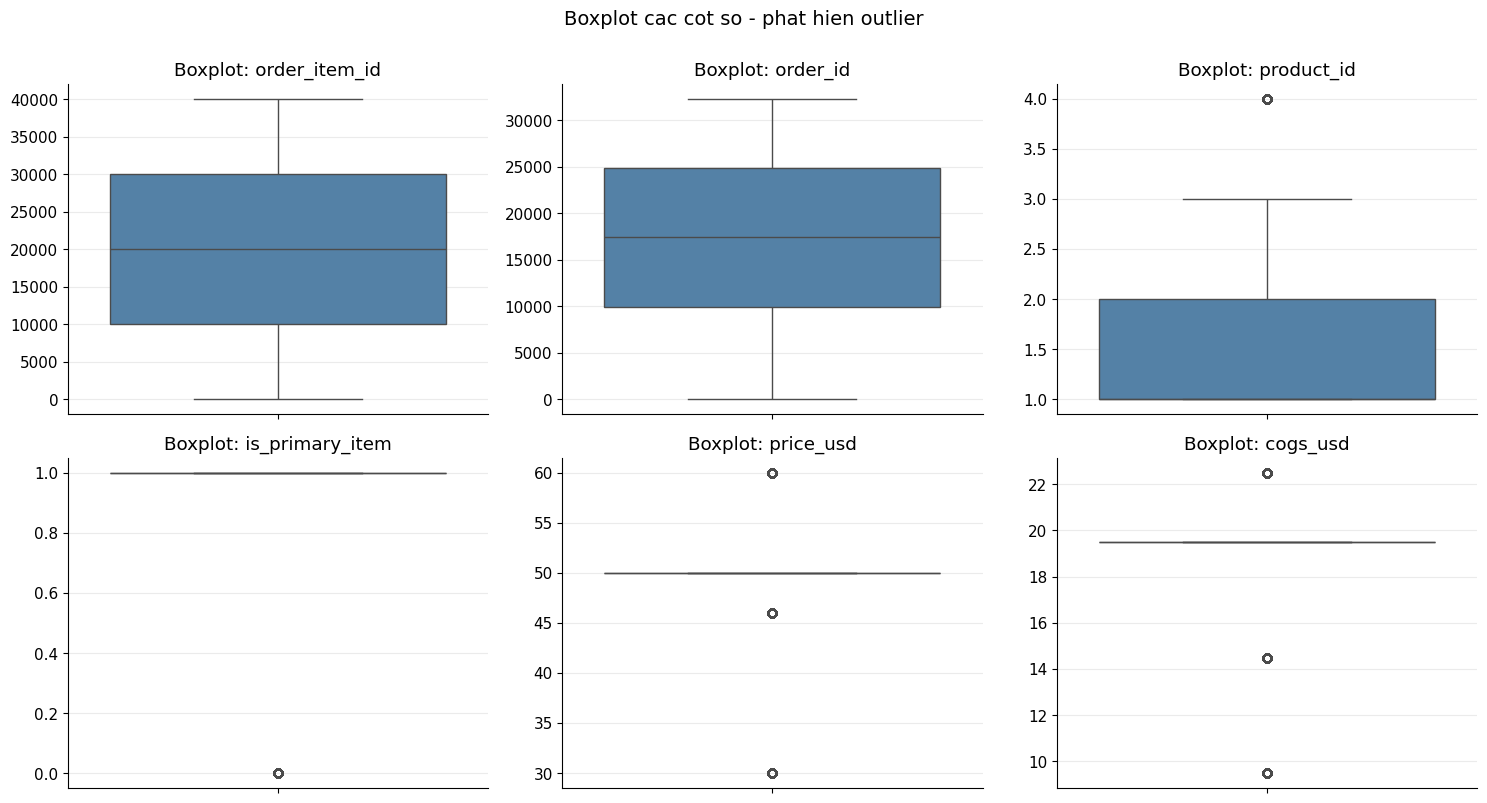


5. GIA TRI THIEU (MISSING VALUES)
Khong co gia tri thieu.


{'n_duplicates': np.int64(0),
 'n_duplicates_key': np.int64(0),
 'missing_summary': Series([], dtype: int64)}

In [ ]:
check_dataframe(order_items, key='order_item_id')

##order_item_refunds

1. METADATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1731 entries, 0 to 1730
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_item_refund_id  1731 non-null   int64  
 1   created_at            1731 non-null   object 
 2   order_item_id         1731 non-null   int64  
 3   order_id              1731 non-null   int64  
 4   refund_amount_usd     1731 non-null   float64
dtypes: float64(1), int64(3), object(1)
memory usage: 67.7+ KB

2. XEM TRUOC 2 DONG DAU


,order_item_refund_id,created_at,order_item_id,order_id,refund_amount_usd
0,1,2012-04-06 11:32:43,57,57,49.99
1,2,2012-04-13 01:09:43,74,74,49.99



3. DU LIEU TRUNG LAP
So dong trung lap toan phan: 0
So gia tri trung lap tren khoa 'order_item_refund_id': 0  (OK - khong trung)

4. THONG KE MO TA (COT SO)


,count,mean,std,min,25%,50%,75%,max
order_item_refund_id,"1,731.00",866.00,499.84,1.00,433.50,866.00,"1,298.50","1,731.00"
order_item_id,"1,731.00","18,472.21","11,438.07",57.00,"7,417.00","19,858.00","26,900.00","39,950.00"
order_id,"1,731.00","15,868.24","9,096.06",57.00,"7,412.00","17,375.00","22,539.50","32,255.00"
refund_amount_usd,"1,731.00",49.30,4.96,29.99,49.99,49.99,49.99,59.99


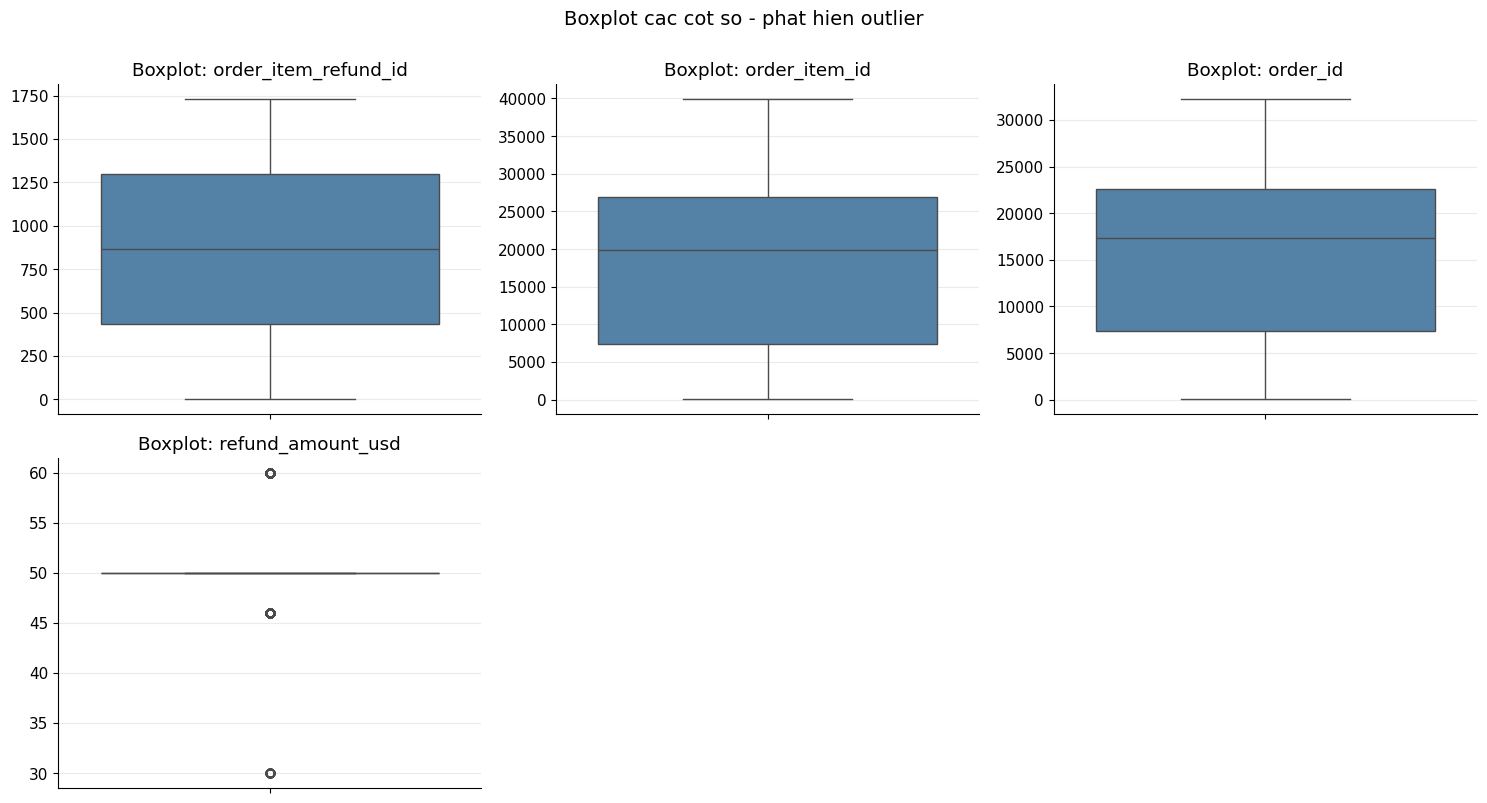


5. GIA TRI THIEU (MISSING VALUES)
Khong co gia tri thieu.


{'n_duplicates': np.int64(0),
 'n_duplicates_key': np.int64(0),
 'missing_summary': Series([], dtype: int64)}

In [ ]:
check_dataframe(order_item_refunds, key='order_item_refund_id')

In [ ]:
check_outlier(order_item_refunds, 'refund_amount_usd', drop_label=True)

THỐNG KÊ OUTLIER DỰA TRÊN IQR - CỘT 'refund_amount_usd'
• Q1 (25%): 49.99
• Q3 (75%): 49.99
• IQR     : 0.00
• Cận dưới (LB): 49.99
• Cận trên (UB): 49.99
-------------------------------------------------------
                           Số lượng  Tỷ lệ (%)
Outlier_refund_amount_usd                     
Normal                         1237      71.46
Outlier                         494      28.54



,order_item_refund_id,created_at,order_item_id,order_id,refund_amount_usd
0,1,2012-04-06 11:32:43,57,57,49.99
1,2,2012-04-13 01:09:43,74,74,49.99
2,3,2012-04-15 07:03:48,71,71,49.99
3,4,2012-04-17 20:00:37,118,118,49.99
4,5,2012-04-22 20:53:49,116,116,49.99
...,...,...,...,...,...
1726,1727,2015-03-30 09:37:23,39950,32255,59.99
1727,1728,2015-03-30 21:33:51,39671,32049,49.99
1728,1729,2015-03-31 19:59:48,39729,32090,49.99
1729,1730,2015-04-01 03:54:48,39717,32079,59.99


##orders

1. METADATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32313 entries, 0 to 32312
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            32313 non-null  int64  
 1   created_at          32313 non-null  object 
 2   website_session_id  32313 non-null  int64  
 3   user_id             32313 non-null  int64  
 4   primary_product_id  32313 non-null  int64  
 5   items_purchased     32313 non-null  int64  
 6   price_usd           32313 non-null  float64
 7   cogs_usd            32313 non-null  float64
dtypes: float64(2), int64(5), object(1)
memory usage: 2.0+ MB

2. XEM TRUOC 2 DONG DAU


,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49



3. DU LIEU TRUNG LAP
So dong trung lap toan phan: 0
So gia tri trung lap tren khoa 'order_id': 0  (OK - khong trung)

4. THONG KE MO TA (COT SO)


,count,mean,std,min,25%,50%,75%,max
order_id,"32,313.00","16,157.00","9,328.10",1.00,"8,079.00","16,157.00","24,235.00","32,313.00"
website_session_id,"32,313.00","258,292.29","132,427.65",20.00,"144,828.00","263,554.00","374,799.00","472,818.00"
user_id,"32,313.00","215,691.62","108,402.20",13.00,"124,135.00","221,461.00","310,542.00","394,273.00"
primary_product_id,"32,313.00",1.39,0.73,1.00,1.00,1.00,2.00,4.00
items_purchased,"32,313.00",1.24,0.43,1.00,1.00,1.00,1.00,2.00
price_usd,"32,313.00",59.99,17.81,29.99,49.99,49.99,59.99,109.98
cogs_usd,"32,313.00",22.36,6.24,9.49,19.49,19.49,22.49,41.98


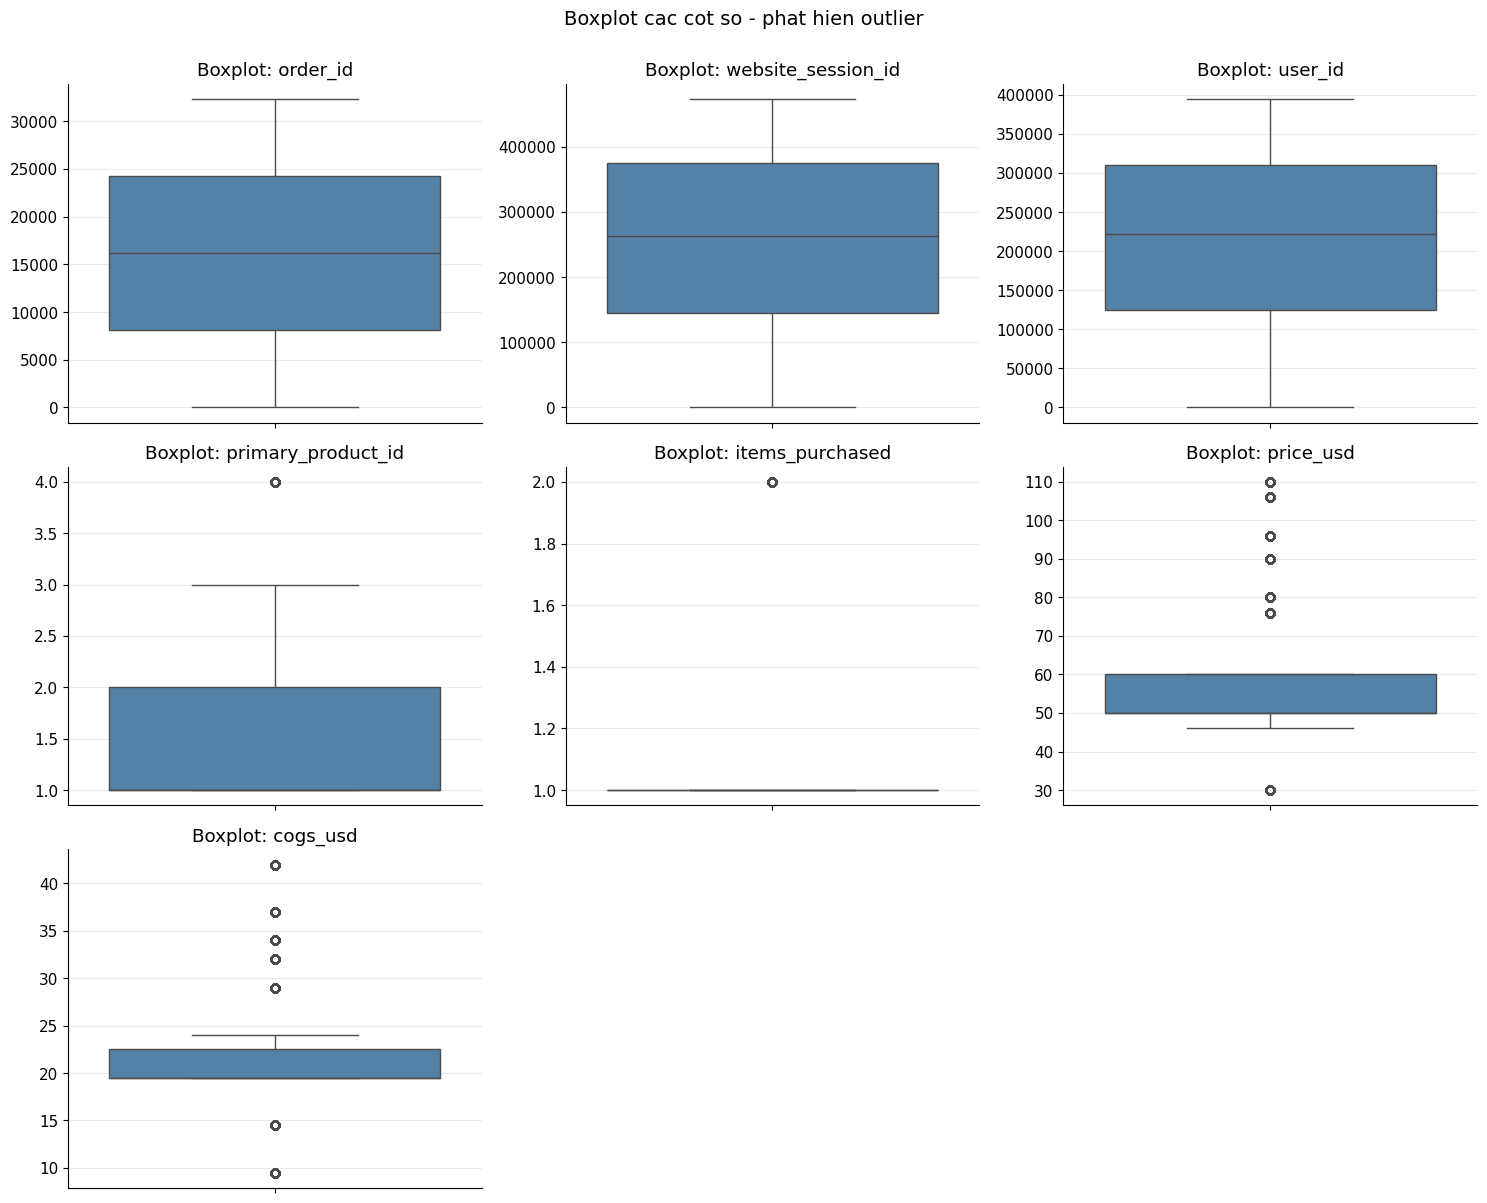


5. GIA TRI THIEU (MISSING VALUES)
Khong co gia tri thieu.


{'n_duplicates': np.int64(0),
 'n_duplicates_key': np.int64(0),
 'missing_summary': Series([], dtype: int64)}

In [ ]:
check_dataframe(orders, key='order_id')

In [ ]:
check_outlier(orders, 'price_usd', drop_label=True)

THỐNG KÊ OUTLIER DỰA TRÊN IQR - CỘT 'price_usd'
• Q1 (25%): 49.99
• Q3 (75%): 59.99
• IQR     : 10.00
• Cận dưới (LB): 34.99
• Cận trên (UB): 74.99
-------------------------------------------------------
                   Số lượng  Tỷ lệ (%)
Outlier_price_usd                     
Normal                24067      74.48
Outlier                8246      25.52



,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49
...,...,...,...,...,...,...,...,...
32308,32309,2015-03-19 03:58:12,472795,394255,1,1,49.99,19.49
32309,32310,2015-03-19 04:10:43,472798,394257,4,1,29.99,9.49
32310,32311,2015-03-19 05:27:28,472809,394268,2,2,89.98,31.98
32311,32312,2015-03-19 05:35:57,472814,394273,4,1,29.99,9.49


##products

1. METADATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   product_id    4 non-null      int64 
 1   created_at    4 non-null      object
 2   product_name  4 non-null      object
dtypes: int64(1), object(2)
memory usage: 228.0+ bytes

2. XEM TRUOC 2 DONG DAU


,product_id,created_at,product_name
0,1,2012-03-19 08:00:00,The Original Mr. Fuzzy
1,2,2013-01-06 13:00:00,The Forever Love Bear



3. DU LIEU TRUNG LAP
So dong trung lap toan phan: 0
So gia tri trung lap tren khoa 'product_id': 0  (OK - khong trung)

4. THONG KE MO TA (COT SO)


,count,mean,std,min,25%,50%,75%,max
product_id,4.00,2.50,1.29,1.00,1.75,2.50,3.25,4.00


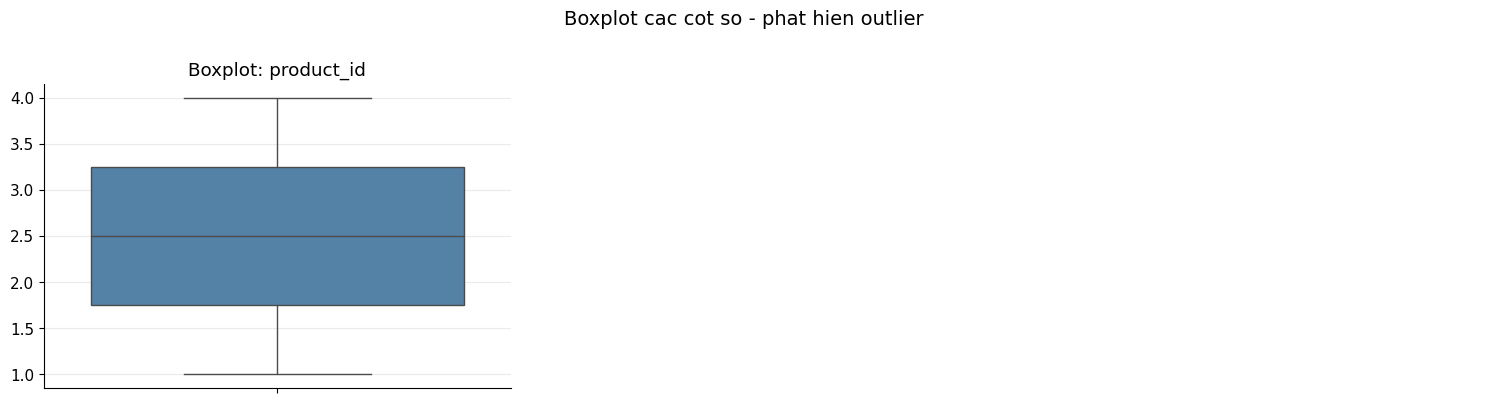


5. GIA TRI THIEU (MISSING VALUES)
Khong co gia tri thieu.


{'n_duplicates': np.int64(0),
 'n_duplicates_key': np.int64(0),
 'missing_summary': Series([], dtype: int64)}

In [ ]:
check_dataframe(products, key='product_id')

##website_pageviews

1. METADATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1188124 entries, 0 to 1188123
Data columns (total 4 columns):
 #   Column               Non-Null Count    Dtype 
---  ------               --------------    ----- 
 0   website_pageview_id  1188124 non-null  int64 
 1   created_at           1188124 non-null  object
 2   website_session_id   1188124 non-null  int64 
 3   pageview_url         1188124 non-null  object
dtypes: int64(2), object(2)
memory usage: 36.3+ MB

2. XEM TRUOC 2 DONG DAU


,website_pageview_id,created_at,website_session_id,pageview_url
0,1,2012-03-19 08:04:16,1,/home
1,2,2012-03-19 08:16:49,2,/home



3. DU LIEU TRUNG LAP
So dong trung lap toan phan: 0
So gia tri trung lap tren khoa 'website_pageview_id': 0  (OK - khong trung)

4. THONG KE MO TA (COT SO)


,count,mean,std,min,25%,50%,75%,max
website_pageview_id,"1,188,124.00","594,062.50","342,982.00",1.00,"297,031.75","594,062.50","891,093.25","1,188,124.00"
website_session_id,"1,188,124.00","244,458.52","135,619.86",1.00,"127,786.00","247,808.00","362,739.00","472,871.00"


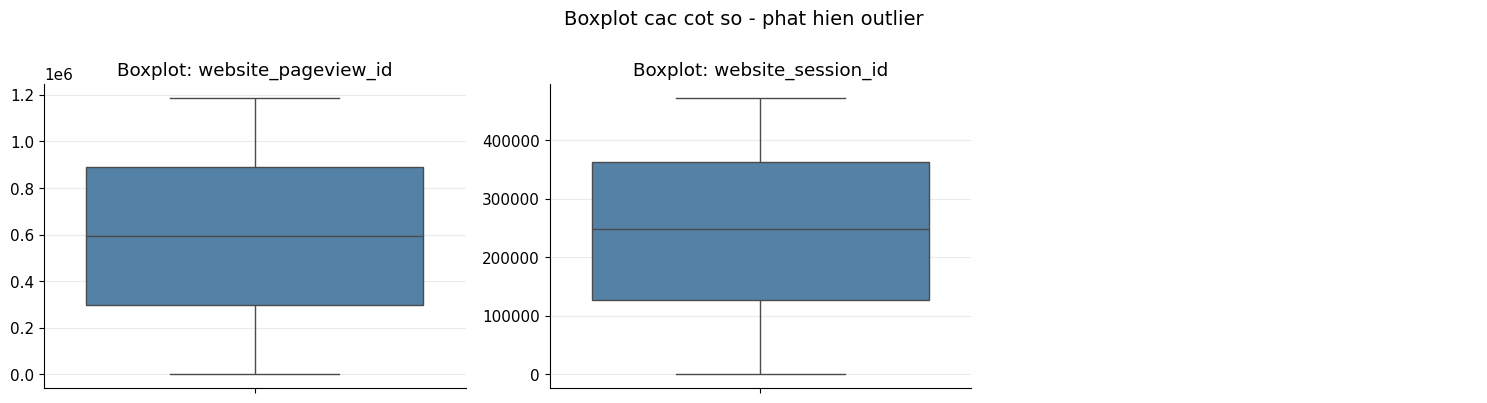


5. GIA TRI THIEU (MISSING VALUES)
Khong co gia tri thieu.


{'n_duplicates': np.int64(0),
 'n_duplicates_key': np.int64(0),
 'missing_summary': Series([], dtype: int64)}

In [ ]:
check_dataframe(website_pageviews, key='website_pageview_id')

## website_sessions

1. METADATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 472871 entries, 0 to 472870
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   website_session_id  472871 non-null  int64 
 1   created_at          472871 non-null  object
 2   user_id             472871 non-null  int64 
 3   is_repeat_session   472871 non-null  int64 
 4   utm_source          389543 non-null  object
 5   utm_campaign        389543 non-null  object
 6   utm_content         389543 non-null  object
 7   device_type         472871 non-null  object
 8   http_referer        432954 non-null  object
dtypes: int64(3), object(6)
memory usage: 32.5+ MB

2. XEM TRUOC 2 DONG DAU


,website_session_id,created_at,user_id,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer
0,1,2012-03-19 08:04:16,1,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com
1,2,2012-03-19 08:16:49,2,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com



3. DU LIEU TRUNG LAP
So dong trung lap toan phan: 0
So gia tri trung lap tren khoa 'website_session_id': 0  (OK - khong trung)

4. THONG KE MO TA (COT SO)


,count,mean,std,min,25%,50%,75%,max
website_session_id,"472,871.00","236,436.00","136,506.24",1.00,"118,218.50","236,436.00","354,653.50","472,871.00"
user_id,"472,871.00","198,037.97","111,993.00",1.00,"101,966.50","199,483.00","294,433.00","394,318.00"
is_repeat_session,"472,871.00",0.17,0.37,0.00,0.00,0.00,0.00,1.00


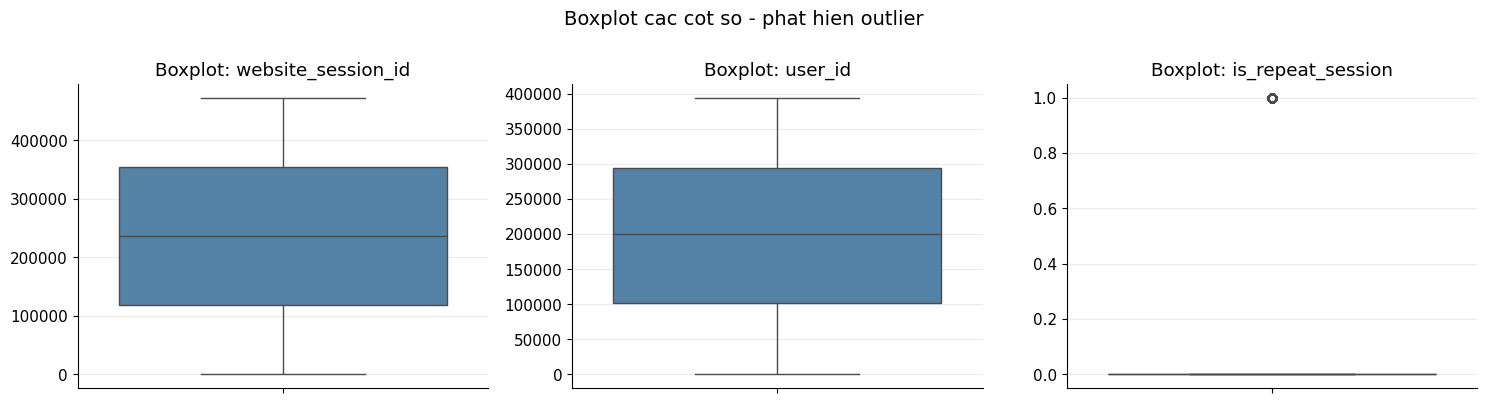


5. GIA TRI THIEU (MISSING VALUES)
utm_source      83328
utm_campaign    83328
utm_content     83328
http_referer    39917
dtype: int64


{'n_duplicates': np.int64(0),
 'n_duplicates_key': np.int64(0),
 'missing_summary': utm_source      83328
 utm_campaign    83328
 utm_content     83328
 http_referer    39917
 dtype: int64}

In [ ]:
check_dataframe(website_sessions, key='website_session_id')

In [ ]:
# Kiểm tra khóa ngoại trước khi merge
checks = {
    'order_items.product_id → products'          : order_items['product_id'].isin(products['product_id']).mean(),
    'order_items.order_id → orders'              : order_items['order_id'].isin(orders['order_id']).mean(),
    'order_item_refunds.order_item_id → order_items': order_item_refunds['order_item_id'].isin(order_items['order_item_id']).mean(),
    'orders.website_session_id → sessions'       : orders['website_session_id'].isin(website_sessions['website_session_id']).mean(),
    'pageviews.website_session_id → sessions'    : website_pageviews['website_session_id'].isin(website_sessions['website_session_id']).mean(),
}
for k, v in checks.items():
    status = 'OK' if v == 1 else 'CẢNH BÁO'
    print(f'[{status:8s}] {k:48s} {v:.2%}')

[OK      ] order_items.product_id → products                100.00%
[OK      ] order_items.order_id → orders                    100.00%
[OK      ] order_item_refunds.order_item_id → order_items   100.00%
[OK      ] orders.website_session_id → sessions             100.00%
[OK      ] pageviews.website_session_id → sessions          100.00%


## Tổng hợp lỗi

- Bảng order_items:
  + Cột created_at chưa chuyển đổi kiểu dữ liệu sang DATE/DATETIME (đang là object)

- Bảng order_item_refunds:
  + Cột created_at chưa chuyển đổi kiểu dữ liệu sang DATE/DATETIME (đang là object)

- Bảng orders:
  + Cột created_at chưa chuyển đổi kiểu dữ liệu sang DATE/DATETIME (đang là object)

- Bảng products:
  + Cột created_at chưa chuyển đổi kiểu dữ liệu sang DATE/DATETIME (đang là object)

- Bảng website_pageviews:
  + Cột created_at chưa chuyển đổi kiểu dữ liệu sang DATE/DATETIME (đang là object)

- Bảng website_sessions:
  + Cột created_at chưa chuyển đổi kiểu dữ liệu sang DATE/DATETIME (đang là object)
  + Cột utm_source, utm_campaign, utm_content thiếu 83.328/472.871 dòng — do các session vào từ traffic không gắn UTM (ví dụ truy cập trực tiếp/organic), không phải lỗi nhập liệu
  + Cột http_referer thiếu 39.917/472.871 dòng — do session không có trang giới thiệu (gõ URL trực tiếp), không phải lỗi nhập liệu
  + Cột device_type chưa chuẩn hóa về chữ thường — cần thống nhất trước khi group theo thiết bị

#Data Cleaning

In [ ]:
#Chuẩn hóa kiểu thời gian + tạo cột month cho toàn bộ bảng
for name, df in TABLES.items():
    df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
    df['month'] = df['created_at'].dt.to_period('M').dt.to_timestamp()
    print(f'{name:22s} dtype={df["created_at"].dtype}  |  lỗi parse: {df["created_at"].isna().sum()}')

order_items            dtype=datetime64[ns]  |  lỗi parse: 0
order_item_refunds     dtype=datetime64[ns]  |  lỗi parse: 0
orders                 dtype=datetime64[ns]  |  lỗi parse: 0
products               dtype=datetime64[ns]  |  lỗi parse: 0
website_pageviews      dtype=datetime64[ns]  |  lỗi parse: 0
website_sessions       dtype=datetime64[ns]  |  lỗi parse: 0


In [ ]:
#Gán nhãn traffic không có UTM
website_sessions['utm_source']   = website_sessions['utm_source'].fillna('direct/organic')
website_sessions['utm_campaign'] = website_sessions['utm_campaign'].fillna('none')
website_sessions['utm_content']  = website_sessions['utm_content'].fillna('none')
website_sessions['http_referer'] = website_sessions['http_referer'].fillna('direct')

#Chuẩn hóa dữ liệu văn bản
website_sessions['device_type'] = website_sessions['device_type'].str.lower().str.strip()

print(website_sessions['utm_source'].value_counts(), '\n')
print(website_sessions['device_type'].value_counts())

utm_source
gsearch           316035
direct/organic     83328
bsearch            62823
socialbook         10685
Name: count, dtype: int64 

device_type
desktop    327027
mobile     145844
Name: count, dtype: int64


In [ ]:
#Kiểm tra danh sách URL thực tế
url_stats = (website_pageviews['pageview_url'].value_counts()
             .reset_index().rename(columns={'count': 'pageviews'}))
url_stats

,pageview_url,pageviews
0,/products,261231
1,/the-original-mr-fuzzy,162525
2,/home,137576
3,/lander-2,131170
4,/cart,94953
5,/lander-3,79000
6,/lander-5,68166
7,/shipping,64484
8,/billing-2,48441
9,/lander-1,47574


In [ ]:
#Xác nhận phạm vi thời gian của dữ liệu
print(f"Từ {orders['created_at'].min():%Y-%m-%d} đến {orders['created_at'].max():%Y-%m-%d}")
print(f"Số khách hàng duy nhất: {orders['user_id'].nunique():,}")

Từ 2012-03-19 đến 2015-03-19
Số khách hàng duy nhất: 31,696


#Executive Overview

In [ ]:
total_sessions = website_sessions['website_session_id'].nunique()
total_orders   = orders['order_id'].nunique()
total_revenue  = orders['price_usd'].sum()
total_cogs     = orders['cogs_usd'].sum()
total_refunds  = order_item_refunds['refund_amount_usd'].sum()

net_profit = total_revenue - total_cogs - total_refunds

summary_metrics = pd.DataFrame({
    'Chỉ số': ['Sessions', 'Orders', 'CR (%)', 'AOV', 'Revenue',
               'COGS', 'Refunds', 'Net Profit', 'Net Margin (%)'],
    'Giá trị': [
        f"{total_sessions:,}", f"{total_orders:,}",
        f"{total_orders/total_sessions*100:.2f}%",
        f"${total_revenue/total_orders:,.2f}",
        f"${total_revenue:,.2f}", f"${total_cogs:,.2f}", f"${total_refunds:,.2f}",
        f"${net_profit:,.2f}", f"{net_profit/total_revenue*100:.2f}%",
    ]
})
summary_metrics

,Chỉ số,Giá trị
0,Sessions,"472,871"
1,Orders,"32,313"
2,CR (%),6.83%
3,AOV,$59.99
4,Revenue,"$1,938,509.75"
5,COGS,"$722,370.25"
6,Refunds,"$85,338.69"
7,Net Profit,"$1,130,800.81"
8,Net Margin (%),58.33%


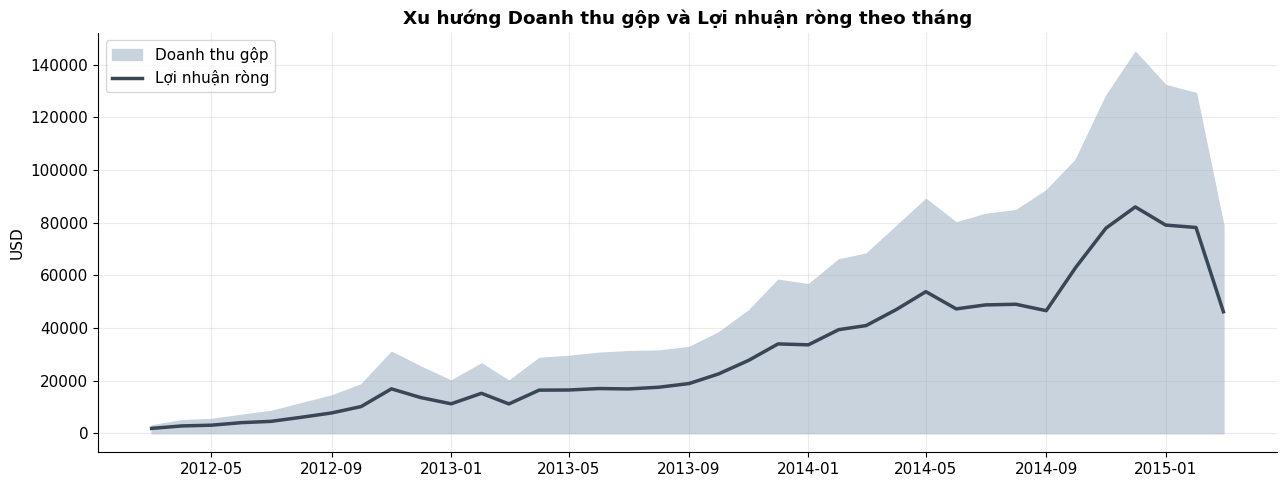

In [ ]:
# Xu hướng doanh thu & lợi nhuận theo tháng
oi_base = order_items.merge(products[['product_id', 'product_name']], on='product_id', how='left')

monthly = orders.groupby('month').agg(
    revenue=('price_usd', 'sum'), cogs=('cogs_usd', 'sum'), n_orders=('order_id', 'nunique')
).reset_index()
ref_m = order_item_refunds.groupby('month')['refund_amount_usd'].sum().reset_index()
monthly = monthly.merge(ref_m, on='month', how='left').fillna({'refund_amount_usd': 0})
monthly['net_profit'] = monthly['revenue'] - monthly['cogs'] - monthly['refund_amount_usd']

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(monthly['month'], monthly['revenue'], color=GREY, label='Doanh thu gộp')
ax.plot(monthly['month'], monthly['net_profit'], color=NAVY, lw=2.5, label='Lợi nhuận ròng')
ax.set_title('Xu hướng Doanh thu gộp và Lợi nhuận ròng theo tháng', fontweight='bold')
ax.set_ylabel('USD'); ax.legend()
save('01_revenue_profit_trend')

#1.Doanh thu & Sản phẩm (Pareto & ABC)

##1.1. Unit Economics theo sản phẩm

In [ ]:
# Gắn tên sản phẩm + số tiền hoàn vào từng dòng order_item
ref_by_item = (order_item_refunds
               .groupby('order_item_id', as_index=False)['refund_amount_usd'].sum())

n_before = len(oi_base)
oi = oi_base.merge(ref_by_item, on='order_item_id', how='left')

# Kiểm tra fan-out
assert len(oi) == n_before, f'Fan-out sau merge refund: {n_before} → {len(oi)}'
print(f'Merge OK, số dòng không đổi: {len(oi):,}')

oi['refund_amount_usd'] = oi['refund_amount_usd'].fillna(0)
oi['is_refunded'] = oi['refund_amount_usd'] > 0
oi['net_profit']  = oi['price_usd'] - oi['cogs_usd'] - oi['refund_amount_usd']

oi[['order_item_id', 'product_name', 'price_usd', 'cogs_usd',
    'refund_amount_usd', 'net_profit']].head(3)

Merge OK, số dòng không đổi: 40,025


,order_item_id,product_name,price_usd,cogs_usd,refund_amount_usd,net_profit
0,1,The Original Mr. Fuzzy,49.99,19.49,0.00,30.50
1,2,The Original Mr. Fuzzy,49.99,19.49,0.00,30.50
2,3,The Original Mr. Fuzzy,49.99,19.49,0.00,30.50


In [ ]:
product_perf = oi.groupby('product_name').agg(
    items_sold     = ('order_item_id', 'count'),
    refunded_items = ('is_refunded', 'sum'),
    gross_revenue  = ('price_usd', 'sum'),
    total_cogs     = ('cogs_usd', 'sum'),
    total_refund   = ('refund_amount_usd', 'sum'),
    net_profit     = ('net_profit', 'sum'),
).reset_index()

product_perf['net_margin_pct']  = product_perf['net_profit'] / product_perf['gross_revenue'] * 100
product_perf['refund_rate_pct'] = product_perf['refunded_items'] / product_perf['items_sold'] * 100
product_perf['rev_share_pct']   = product_perf['gross_revenue'] / product_perf['gross_revenue'].sum() * 100

product_perf = product_perf.sort_values('gross_revenue', ascending=False).reset_index(drop=True)
product_perf

,product_name,items_sold,refunded_items,gross_revenue,total_cogs,total_refund,net_profit,net_margin_pct,refund_rate_pct,rev_share_pct
0,The Original Mr. Fuzzy,24226,1237,"1,211,057.74","472,164.74","61,837.63","677,055.37",55.91,5.11,62.47
1,The Forever Love Bear,5796,129,"347,702.04","130,352.04","7,738.71","209,611.29",60.28,2.23,17.94
2,The Birthday Sugar Panda,4985,301,"229,260.15","72,232.65","13,842.99","143,184.51",62.46,6.04,11.83
3,The Hudson River Mini bear,5018,64,"150,489.82","47,620.82","1,919.36","100,949.64",67.08,1.28,7.76


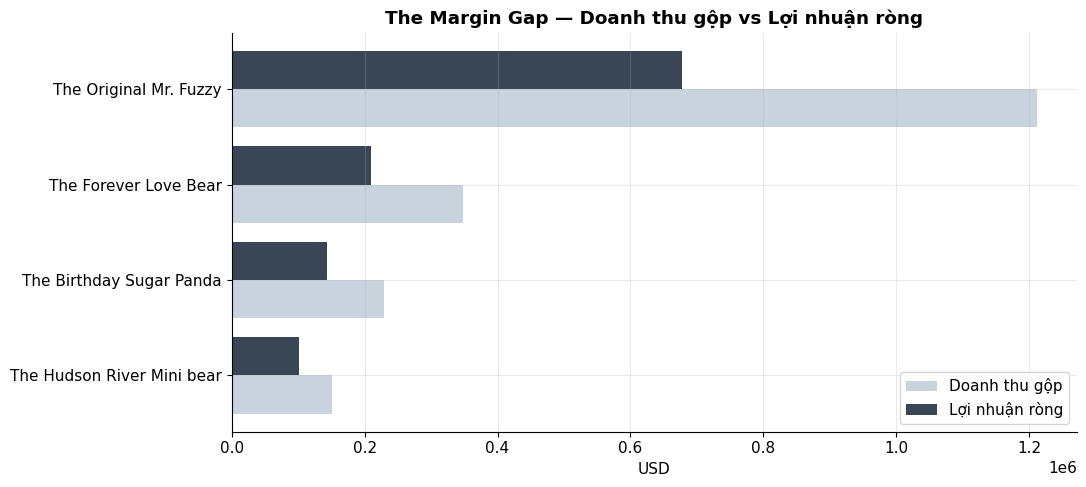

In [ ]:
# Khoảng trống lợi nhuận: Doanh thu gộp vs Lợi nhuận ròng
fig, ax = plt.subplots(figsize=(11, 5))
y = np.arange(len(product_perf))
ax.barh(y + 0.2, product_perf['gross_revenue'], height=0.4, color=GREY, label='Doanh thu gộp')
ax.barh(y - 0.2, product_perf['net_profit'],    height=0.4, color=NAVY, label='Lợi nhuận ròng')
ax.set_yticks(y); ax.set_yticklabels(product_perf['product_name'])
ax.invert_yaxis(); ax.set_xlabel('USD'); ax.legend()
ax.set_title('The Margin Gap — Doanh thu gộp vs Lợi nhuận ròng', fontweight='bold')
save('02_margin_gap')

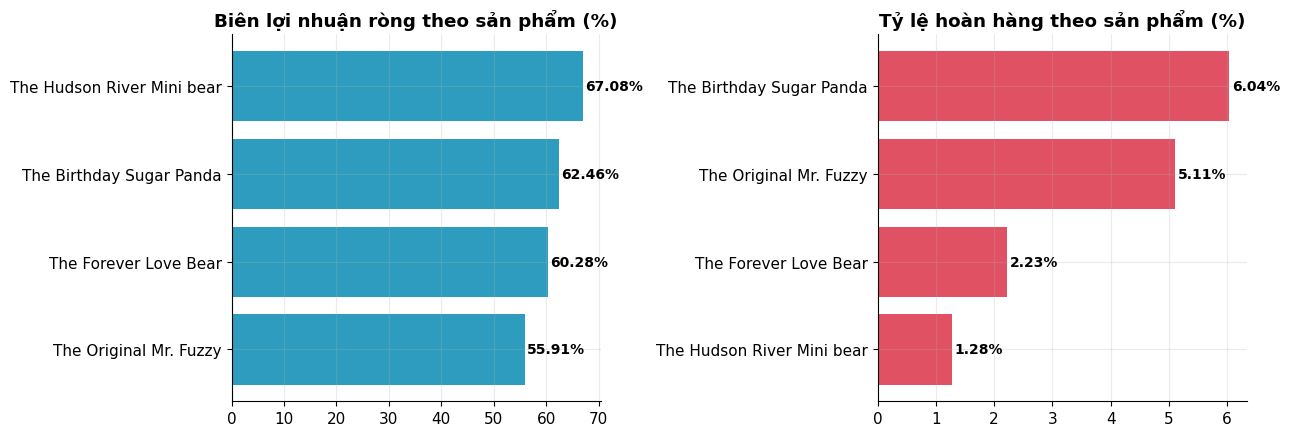

In [ ]:
# Biên lợi nhuận ròng & Tỷ lệ hoàn tiền
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

d = product_perf.sort_values('net_margin_pct')
axes[0].barh(d['product_name'], d['net_margin_pct'], color=TEAL)
axes[0].set_title('Biên lợi nhuận ròng theo sản phẩm (%)', fontweight='bold')
for i, v in enumerate(d['net_margin_pct']):
    axes[0].text(v + 0.4, i, f'{v:.2f}%', va='center', fontsize=10, fontweight='bold')

d2 = product_perf.sort_values('refund_rate_pct')
axes[1].barh(d2['product_name'], d2['refund_rate_pct'], color=RED)
axes[1].set_title('Tỷ lệ hoàn hàng theo sản phẩm (%)', fontweight='bold')
for i, v in enumerate(d2['refund_rate_pct']):
    axes[1].text(v + 0.05, i, f'{v:.2f}%', va='center', fontsize=10, fontweight='bold')

save('03_margin_refund_by_product')

##1.2. Pareto 80/20 & Phân loại ABC

In [ ]:
pareto = product_perf.sort_values('net_profit', ascending=False).copy()
pareto['cum_profit']     = pareto['net_profit'].cumsum()
pareto['cum_profit_pct'] = pareto['cum_profit'] / pareto['net_profit'].sum() * 100
pareto['ABC'] = pd.cut(pareto['cum_profit_pct'], bins=[0, 80, 95, 100],
                       labels=['A', 'B', 'C'], include_lowest=True)

pareto[['product_name', 'net_profit', 'cum_profit_pct', 'ABC']]

,product_name,net_profit,cum_profit_pct,ABC
0,The Original Mr. Fuzzy,"677,055.37",59.87,A
1,The Forever Love Bear,"209,611.29",78.41,A
2,The Birthday Sugar Panda,"143,184.51",91.07,B
3,The Hudson River Mini bear,"100,949.64",100.00,C


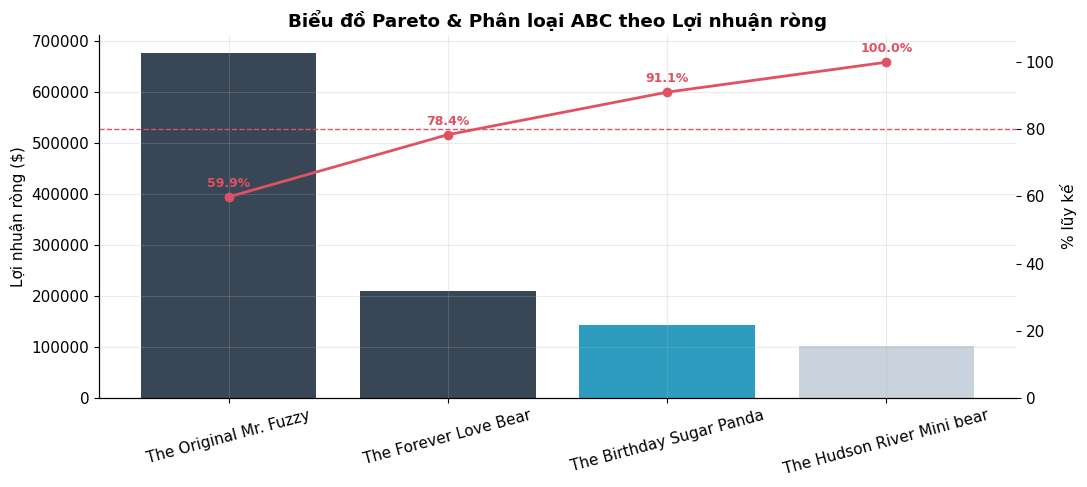

In [ ]:
fig, ax1 = plt.subplots(figsize=(11, 5))
colors = {'A': NAVY, 'B': TEAL, 'C': GREY}
ax1.bar(pareto['product_name'], pareto['net_profit'],
        color=[colors[c] for c in pareto['ABC']])
ax1.set_ylabel('Lợi nhuận ròng ($)'); ax1.tick_params(axis='x', rotation=15)

ax2 = ax1.twinx()
ax2.plot(pareto['product_name'], pareto['cum_profit_pct'], color=RED, marker='o', lw=2)
ax2.axhline(80, color=RED, ls='--', lw=1)
ax2.set_ylabel('% lũy kế'); ax2.set_ylim(0, 108); ax2.grid(False)
for x, v in zip(pareto['product_name'], pareto['cum_profit_pct']):
    ax2.text(x, v + 3, f'{v:.1f}%', ha='center', fontsize=9, color=RED, fontweight='bold')

plt.title('Biểu đồ Pareto & Phân loại ABC theo Lợi nhuận ròng', fontweight='bold')
save('04_pareto_abc')

In [ ]:
# Pareto theo nguồn traffic
marketing = orders.merge(
    website_sessions[['website_session_id', 'utm_source']],
    on='website_session_id', how='left')

source_sales = (marketing.groupby('utm_source')['price_usd'].sum()
                .reset_index().sort_values('price_usd', ascending=False))
source_sales['cum_pct'] = source_sales['price_usd'].cumsum() / source_sales['price_usd'].sum() * 100
source_sales

,utm_source,price_usd,cum_pct
2,gsearch,"1,276,144.89",65.83
1,direct/organic,"371,433.03",84.99
0,bsearch,"268,672.50",98.85
3,socialbook,"22,259.33",100.00


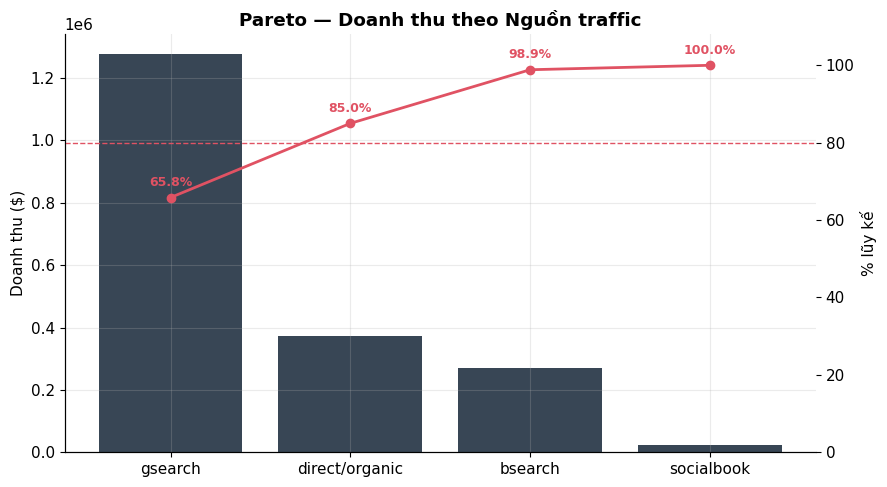

In [ ]:
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.bar(source_sales['utm_source'], source_sales['price_usd'], color=NAVY)
ax1.set_ylabel('Doanh thu ($)')

ax2 = ax1.twinx()
ax2.plot(source_sales['utm_source'], source_sales['cum_pct'], color=RED, marker='o', lw=2)
ax2.axhline(80, color=RED, ls='--', lw=1)
ax2.set_ylabel('% lũy kế'); ax2.set_ylim(0, 108); ax2.grid(False)
for x, v in zip(source_sales['utm_source'], source_sales['cum_pct']):
    ax2.text(x, v + 3, f'{v:.1f}%', ha='center', fontsize=9, color=RED, fontweight='bold')

plt.title('Pareto — Doanh thu theo Nguồn traffic', fontweight='bold')
save('04b_pareto_source')

In [ ]:
# ABC trên khách hàng theo doanh thu
cust_value = (orders.groupby('user_id')['price_usd'].sum()
              .reset_index(name='total_revenue')
              .sort_values('total_revenue', ascending=False).reset_index(drop=True))
cust_value['cum_pct'] = cust_value['total_revenue'].cumsum() / cust_value['total_revenue'].sum() * 100
cust_value['Group'] = pd.cut(cust_value['cum_pct'], bins=[0, 80, 95, 100],
                             labels=['A', 'B', 'C'], include_lowest=True)

group_summary = cust_value.groupby('Group', observed=True).agg(
    NumCustomers=('user_id', 'count'), Revenue=('total_revenue', 'sum')).reset_index()
group_summary['PctCustomers'] = group_summary['NumCustomers'] / group_summary['NumCustomers'].sum() * 100
group_summary['PctRevenue']   = group_summary['Revenue'] / group_summary['Revenue'].sum() * 100
group_summary

,Group,NumCustomers,Revenue,PctCustomers,PctRevenue
0,A,23581,"1,550,788.90",74.40,80.00
1,B,5831,"290,775.69",18.40,15.00
2,C,2284,"96,945.16",7.21,5.00


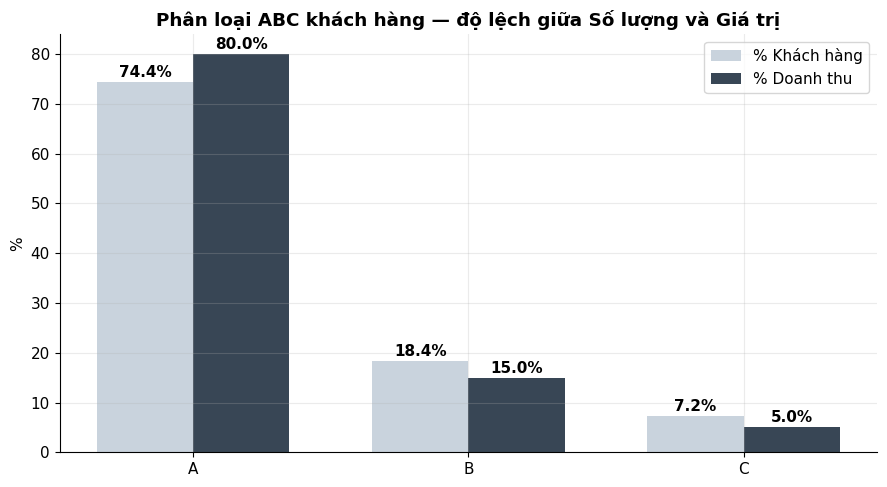

In [ ]:
# Bar đôi: % số lượng khách hàng vs % doanh thu
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(group_summary)); width = 0.35

ax.bar(x - width/2, group_summary['PctCustomers'], width, label='% Khách hàng', color=GREY)
ax.bar(x + width/2, group_summary['PctRevenue'],   width, label='% Doanh thu',  color=NAVY)
ax.set_xticks(x); ax.set_xticklabels(group_summary['Group'])
ax.set_ylabel('%'); ax.legend()
ax.set_title('Phân loại ABC khách hàng — độ lệch giữa Số lượng và Giá trị', fontweight='bold')

for i, row in group_summary.iterrows():
    ax.text(i - width/2, row['PctCustomers'] + 1, f"{row['PctCustomers']:.1f}%", ha='center', fontweight='bold')
    ax.text(i + width/2, row['PctRevenue'] + 1,   f"{row['PctRevenue']:.1f}%",   ha='center', fontweight='bold')

save('04c_abc_customer')

#2.Phân tích Khách hàng (RFM & Cohort)

##2.1. RFM Score & Phân nhóm khách hàng

In [ ]:
snapshot = orders['created_at'].max() + pd.Timedelta(days=1)

rfm = orders.groupby('user_id').agg(
    recency   = ('created_at', lambda x: (snapshot - x.max()).days),
    frequency = ('order_id', 'nunique'),
    monetary  = ('price_usd', 'sum'),
).reset_index()

print(f'Tổng khách hàng: {len(rfm):,}')
print(rfm[['recency', 'frequency', 'monetary']].describe())

Tổng khách hàng: 31,696
        recency  frequency  monetary
count 31,696.00  31,696.00 31,696.00
mean     340.26       1.02     61.16
std      266.68       0.14     20.16
min        1.00       1.00     29.99
25%      111.00       1.00     49.99
50%      282.00       1.00     49.99
75%      506.00       1.00     75.98
max    1,095.00       3.00    251.94


In [ ]:
# Chấm điểm R và M
def qcut_score(series, labels_desc=False):
    labels = [5, 4, 3, 2, 1] if labels_desc else [1, 2, 3, 4, 5]
    return pd.qcut(series.rank(method='first'), q=5, labels=labels).astype(int)

rfm['R_score'] = qcut_score(rfm['recency'],  labels_desc=True)
rfm['M_score'] = qcut_score(rfm['monetary'], labels_desc=False)
rfm.head()

,user_id,recency,frequency,monetary,R_score,M_score
0,13,1058,1,49.99,1,1
1,20,1095,1,49.99,1,1
2,59,1064,1,49.99,1,1
3,104,1095,1,49.99,1,1
4,147,1094,1,49.99,1,1


In [ ]:
# Kiểm tra mức độ lệch của frequency trước khi chấm điểm F
print(rfm['frequency'].describe())
print("\nSố giá trị frequency duy nhất:", rfm['frequency'].nunique())
print("\nPhân bổ:\n", rfm['frequency'].value_counts().sort_index())

test_qcut = pd.qcut(rfm['frequency'], q=5, duplicates='drop')
print("\nSố nhóm thực tế nếu qcut thô:", test_qcut.cat.categories.size)

count   31,696.00
mean         1.02
std          0.14
min          1.00
25%          1.00
50%          1.00
75%          1.00
max          3.00
Name: frequency, dtype: float64

Số giá trị frequency duy nhất: 3

Phân bổ:
 frequency
1    31105
2      565
3       26
Name: count, dtype: int64

Số nhóm thực tế nếu qcut thô: 1


In [ ]:
# Chấm điểm F trên GIÁ TRỊ DUY NHẤT
def dedupe_qcut_score(series, q=5, labels_desc=False):
    """Chấm điểm 1-q dựa trên quantile của các GIÁ TRỊ DUY NHẤT (không phải toàn bộ dòng).
    Đảm bảo 2 khách có giá trị bằng nhau tuyệt đối luôn nhận cùng 1 điểm."""
    labels = [5, 4, 3, 2, 1] if labels_desc else [1, 2, 3, 4, 5]
    unique_values = sorted(series.unique())
    score_lookup = pd.qcut(unique_values, q=q, labels=labels, duplicates='drop').astype(int)
    value_to_score = dict(zip(unique_values, score_lookup))
    result = series.map(value_to_score)
    assert result.isna().sum() == 0, f"Có giá trị chưa map được score — kiểm tra lại '{series.name}'"
    return result

rfm['F_score'] = dedupe_qcut_score(rfm['frequency'], labels_desc=False)
rfm['RFM_Score'] = rfm['R_score']*100 + rfm['F_score']*10 + rfm['M_score']
rfm.head()

,user_id,recency,frequency,monetary,R_score,M_score,F_score,RFM_Score
0,13,1058,1,49.99,1,1,1,111
1,20,1095,1,49.99,1,1,1,111
2,59,1064,1,49.99,1,1,1,111
3,104,1095,1,49.99,1,1,1,111
4,147,1094,1,49.99,1,1,1,111


In [ ]:
# Gắn segment
segment_map = {
    'Champions':             [555,554,544,545,454,455,445],
    'Loyal':                 [543,444,435,355,354,345,344,335],
    'Potential Loyalist':    [553,551,552,541,542,533,532,531,452,451,442,441,431,453,433,432,423,353,352,351,342,341,333,323],
    'Promising':             [525,524,523,522,521,515,514,513,425,424,413,414,415,315,314,313],
    'New Customers':         [512,511,422,421,412,411,311],
    'Need Attention':        [535,534,443,434,343,334,325,324],
    'About To Sleep':        [331,321,312,221,213,231,241,251],
    'At Risk':               [255,254,245,244,253,252,243,242,235,234,225,224,153,152,145,143,142,135,134,133,125,124],
    "Can't Lose Them":       [155,154,144,214,215,115,114,113],
    'Hibernating customers': [332,322,233,232,223,222,132,123,122,212,211],
    'Lost customers':        [111,112,121,131,141,151],
}
score_to_segment = {s: seg for seg, scores in segment_map.items() for s in scores}
rfm['RFM_Segment'] = rfm['RFM_Score'].map(score_to_segment).fillna('Other')

n_other = (rfm['RFM_Segment'] == 'Other').sum()
print("Số dòng chưa map được segment:", n_other)
rfm['RFM_Segment'].value_counts()

Số dòng chưa map được segment: 0


,count
RFM_Segment,
Promising,15928
Lost customers,5620
Hibernating customers,4388
Can't Lose Them,2502
New Customers,2109
About To Sleep,562
Loyal,245
At Risk,168
Need Attention,160


In [ ]:
seg = rfm.groupby('RFM_Segment').agg(
    total_customers=('user_id', 'count'),
    total_revenue=('monetary', 'sum'),
    avg_revenue_per_customer=('monetary', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_recency=('recency', 'mean'),
).reset_index().sort_values('total_revenue', ascending=False)

seg['cust_pct'] = seg['total_customers'] / seg['total_customers'].sum() * 100
seg['rev_pct']  = seg['total_revenue'] / seg['total_revenue'].sum() * 100
seg

,RFM_Segment,total_customers,total_revenue,avg_revenue_per_customer,avg_frequency,avg_recency,cust_pct,rev_pct
9,Promising,15928,"1,068,715.76",67.10,1.00,152.87,50.25,55.13
5,Lost customers,5620,"280,943.80",49.99,1.00,784.25,17.73,14.49
4,Hibernating customers,4388,"217,940.12",49.67,1.00,468.03,13.84,11.24
2,Can't Lose Them,2502,"180,172.22",72.01,1.00,502.56,7.89,9.29
8,New Customers,2109,"88,896.91",42.15,1.00,135.91,6.65,4.59
6,Loyal,245,"32,889.08",134.24,2.01,218.77,0.77,1.70
0,About To Sleep,562,"28,094.38",49.99,1.00,336.32,1.77,1.45
7,Need Attention,160,"19,661.73",122.89,2.00,42.67,0.50,1.01
1,At Risk,168,"18,560.31",110.48,2.03,561.62,0.53,0.96
3,Champions,14,"2,635.44",188.25,3.00,56.21,0.04,0.14


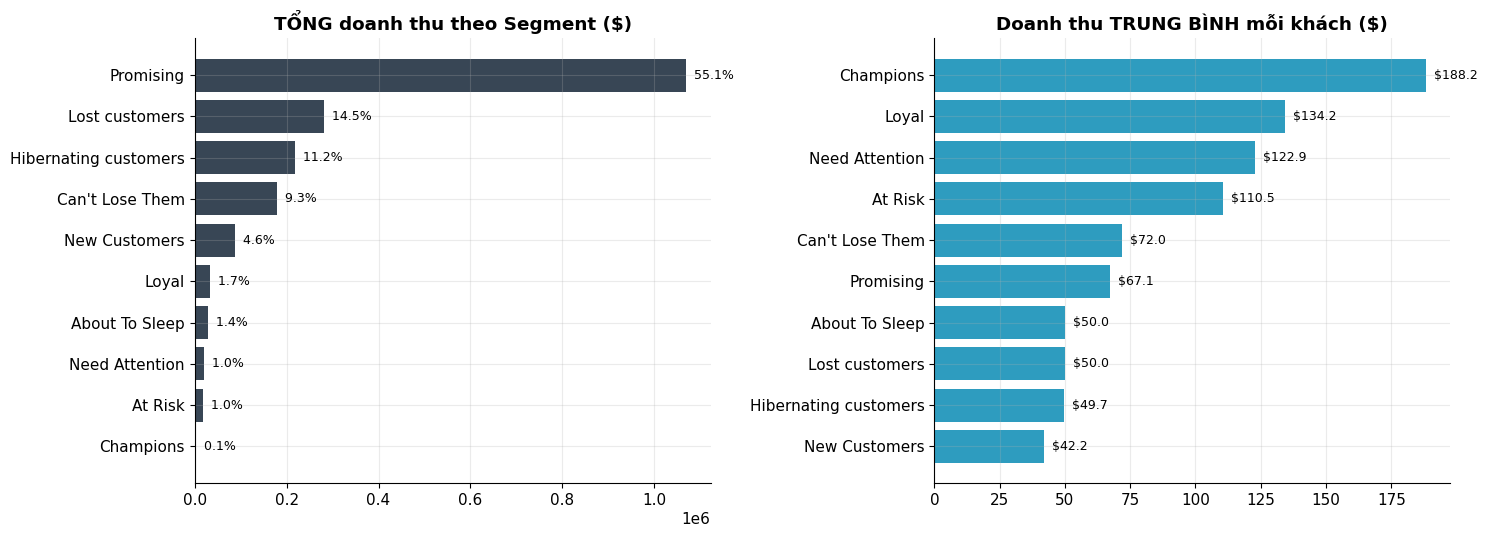

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

s1 = seg.sort_values('total_revenue')
axes[0].barh(s1['RFM_Segment'], s1['total_revenue'], color=NAVY)
axes[0].set_title('TỔNG doanh thu theo Segment ($)', fontweight='bold')
for i, (v, p) in enumerate(zip(s1['total_revenue'], s1['rev_pct'])):
    axes[0].text(v, i, f'  {p:.1f}%', va='center', fontsize=9)

s2 = seg.sort_values('avg_revenue_per_customer')
axes[1].barh(s2['RFM_Segment'], s2['avg_revenue_per_customer'], color=TEAL)
axes[1].set_title('Doanh thu TRUNG BÌNH mỗi khách ($)', fontweight='bold')
for i, v in enumerate(s2['avg_revenue_per_customer']):
    axes[1].text(v, i, f'  ${v:.1f}', va='center', fontsize=9)

save('05_rfm_segment')

## 2.2. Cohort Analysis & Retention Rate

In [ ]:
#Pre cohort
df_pre_cohort = orders[['user_id', 'created_at']].drop_duplicates().reset_index(drop=True)

# Ngày mua đầu tiên
df_first_date = (df_pre_cohort.groupby('user_id', as_index=False)
                 .agg(First_date=('created_at', 'min')))
df_first_date['First_month'] = df_first_date['First_date'].dt.to_period('M')

df_first_date.head(2)

,user_id,First_date,First_month
0,13,2012-04-25 21:05:32,2012-04
1,20,2012-03-19 10:42:46,2012-03


In [ ]:
o = orders.merge(df_first_date, on='user_id', how='left')
o[['user_id', 'created_at', 'First_date', 'First_month']].head()

,user_id,created_at,First_date,First_month
0,20,2012-03-19 10:42:46,2012-03-19 10:42:46,2012-03
1,104,2012-03-19 19:27:37,2012-03-19 19:27:37,2012-03
2,147,2012-03-20 06:44:45,2012-03-20 06:44:45,2012-03
3,160,2012-03-20 09:41:45,2012-03-20 09:41:45,2012-03
4,177,2012-03-20 11:28:15,2012-03-20 11:28:15,2012-03


In [ ]:
o['month_after'] = (
    (o['created_at'].dt.year - o['First_date'].dt.year) * 12 +
    (o['created_at'].dt.month - o['First_date'].dt.month)
)

o[['user_id', 'First_month', 'created_at', 'month_after']] \
    .sort_values('month_after', ascending=False).head()

,user_id,First_month,created_at,month_after
27977,276897,2014-09,2015-01-17 00:39:54,4
3605,46728,2012-11,2013-03-13 08:42:16,4
29302,308016,2014-11,2015-02-05 10:50:21,3
15719,190874,2014-03,2014-06-01 09:28:04,3
6385,82616,2013-05,2013-08-12 18:42:31,3


In [ ]:
df_cohort = o.pivot_table(index='First_month',
                          columns='month_after',
                          values='user_id',
                          aggfunc='nunique')
df_cohort

month_after,0,1,2,3,4
First_month,,,,,
2012-03,60.00,NaN,NaN,NaN,NaN
2012-04,99.00,NaN,NaN,NaN,NaN
2012-05,108.00,NaN,NaN,NaN,NaN
2012-06,139.00,1.00,NaN,NaN,NaN
2012-07,168.00,NaN,NaN,NaN,NaN
2012-08,227.00,1.00,NaN,NaN,NaN
2012-09,286.00,1.00,3.00,NaN,NaN
2012-10,368.00,2.00,NaN,NaN,NaN
2012-11,612.00,2.00,1.00,NaN,1.00


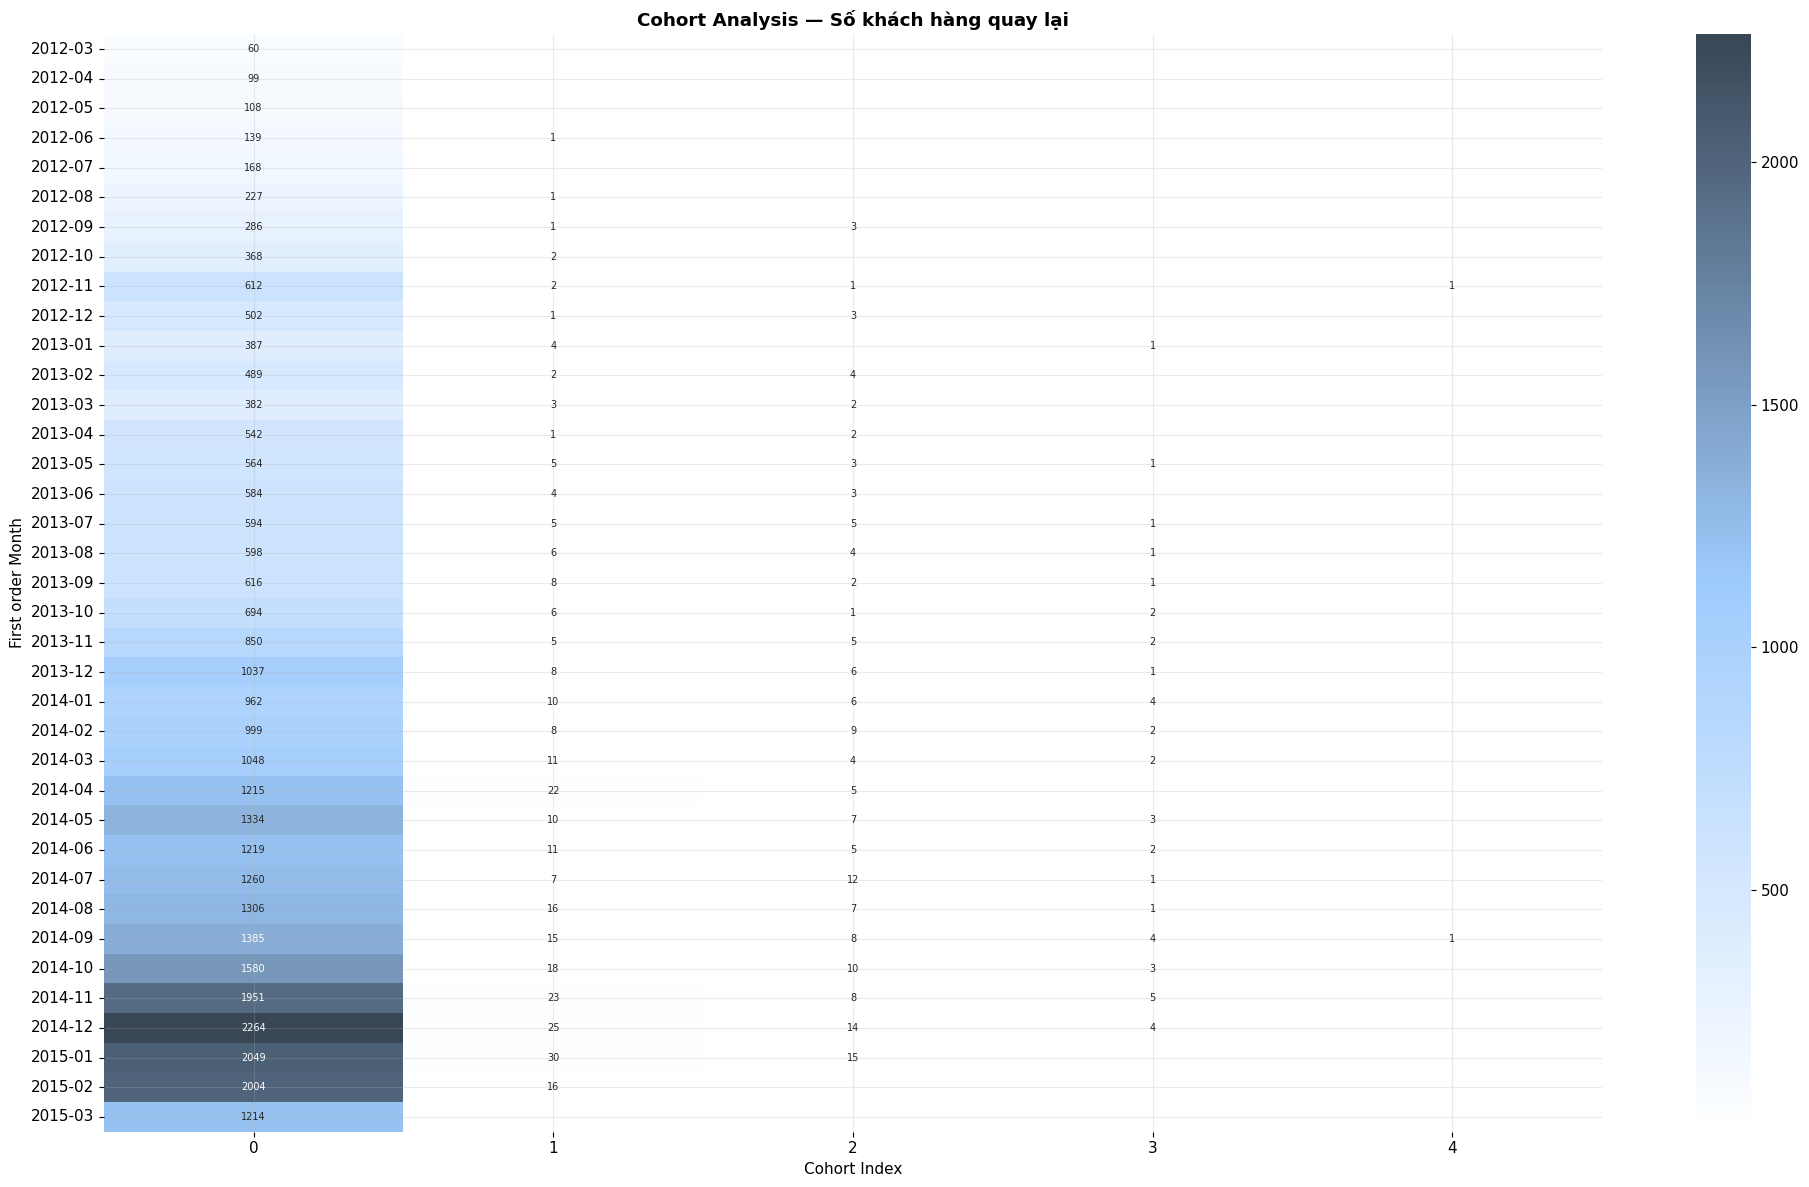

In [ ]:
plt.figure(figsize=(20, 12))
sns.heatmap(data=df_cohort.iloc[:, :13], annot=True, cmap=CMAP, fmt='g',
            annot_kws={'size': 7})
plt.xlabel('Cohort Index')
plt.ylabel('First order Month')
plt.title('Cohort Analysis — Số khách hàng quay lại', fontweight='bold')
save('06_cohort_counts')

In [ ]:
cohort_size = df_cohort.iloc[:, 0]          # cột 0 = tháng gia nhập, luôn 100%
retention_matrix = df_cohort.divide(cohort_size, axis=0)
retention_matrix.iloc[:10, :10]

month_after,0,1,2,3,4
First_month,,,,,
2012-03,1.00,NaN,NaN,NaN,NaN
2012-04,1.00,NaN,NaN,NaN,NaN
2012-05,1.00,NaN,NaN,NaN,NaN
2012-06,1.00,0.01,NaN,NaN,NaN
2012-07,1.00,NaN,NaN,NaN,NaN
2012-08,1.00,0.00,NaN,NaN,NaN
2012-09,1.00,0.00,0.01,NaN,NaN
2012-10,1.00,0.01,NaN,NaN,NaN
2012-11,1.00,0.00,0.00,NaN,0.00


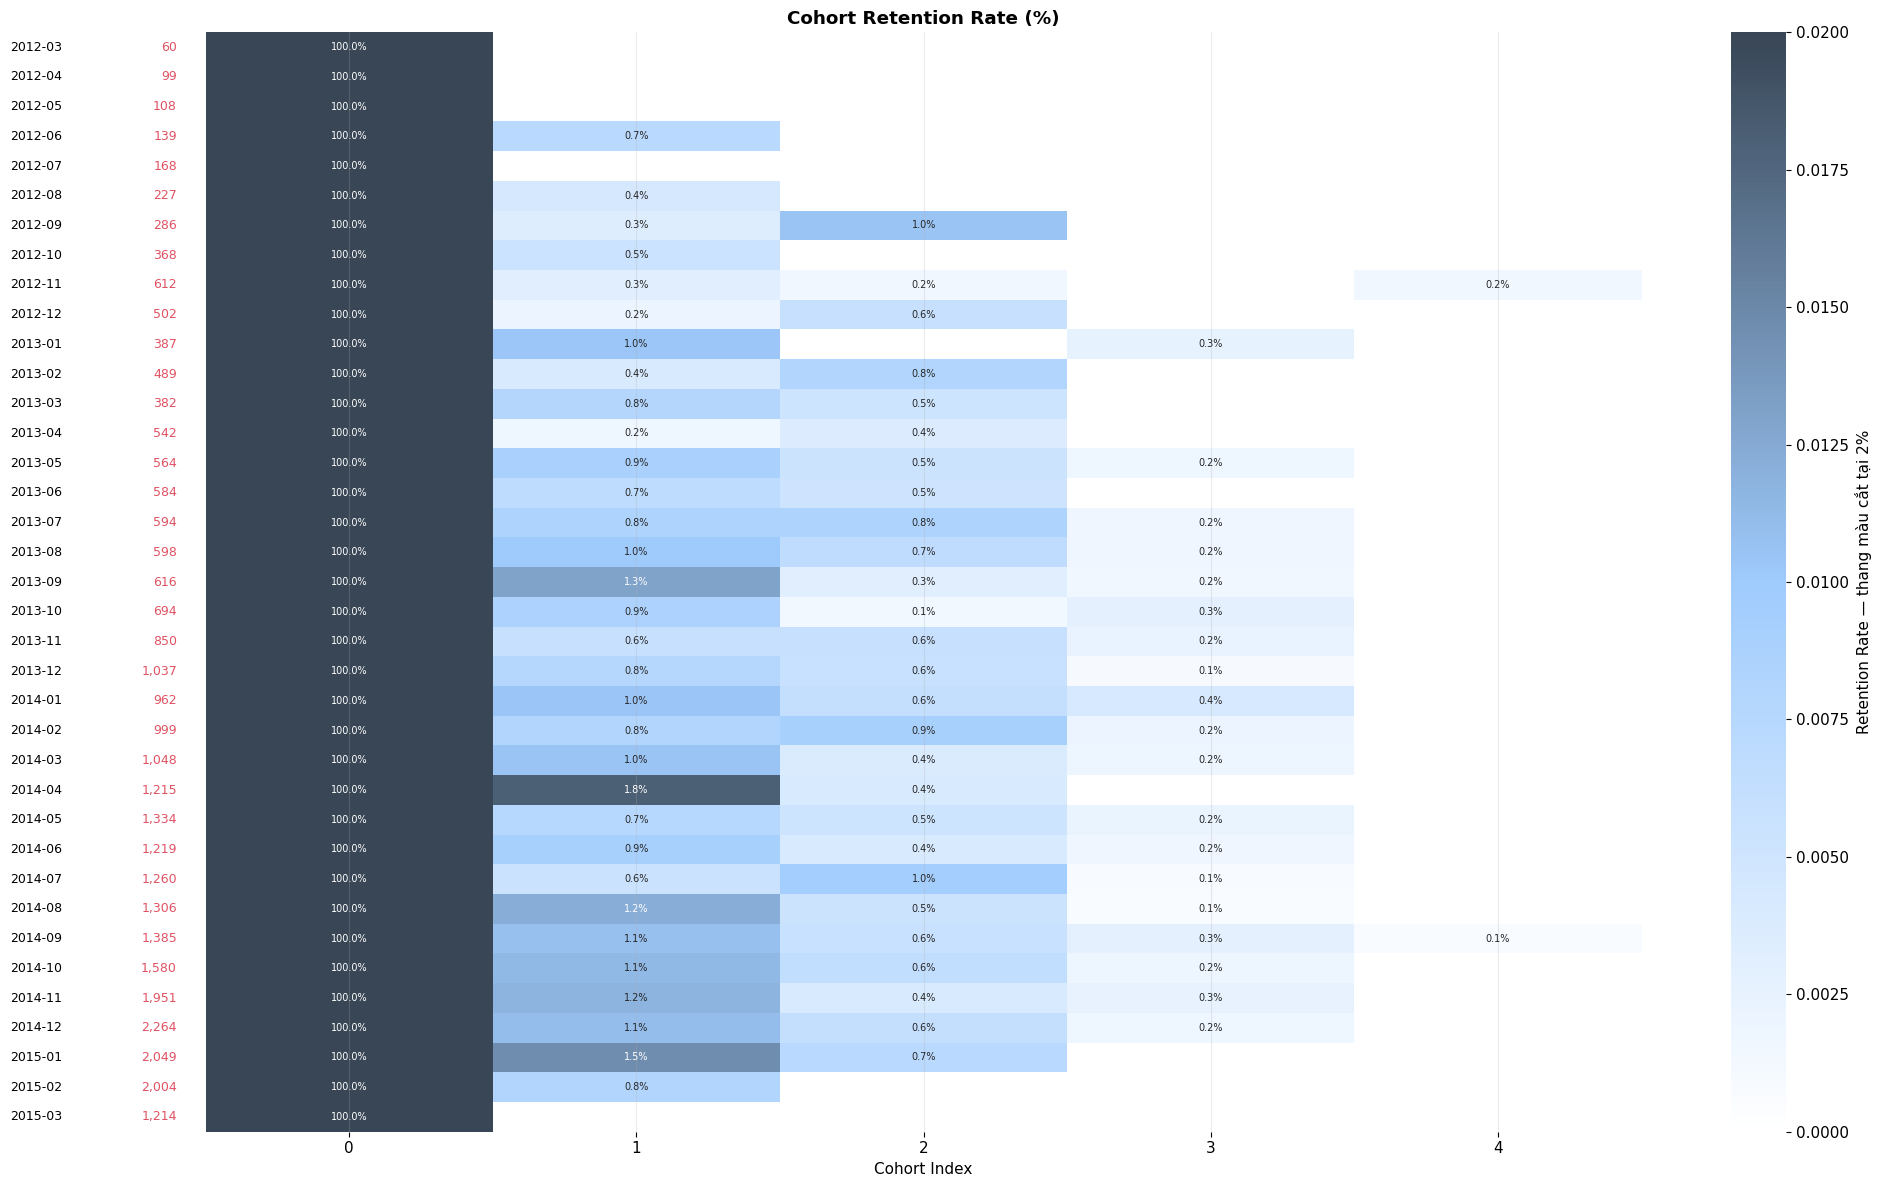

In [ ]:
fig, ax = plt.subplots(figsize=(20, 12))
sns.heatmap(data=retention_matrix.iloc[:, :13], annot=True, cmap=CMAP,
            fmt='.1%', vmin=0, vmax=0.02, ax=ax, annot_kws={'size': 7},
            cbar_kws={'label': 'Retention Rate — thang màu cắt tại 2%'})

ax.set_yticks([])
ax.set_ylabel('')

for i, (period, size) in enumerate(zip(retention_matrix.index.astype(str), cohort_size)):
    # Tháng — màu đen, nằm XA heatmap hơn
    ax.text(-0.10, i + 0.5, period,
            ha='right', va='center', color='black', fontsize=9,
            transform=ax.get_yaxis_transform())
    # Cohort size — màu đỏ, nằm GẦN heatmap hơn
    ax.text(-0.02, i + 0.5, f"{int(size):,}",
            ha='right', va='center', color=RED, fontsize=9,
            transform=ax.get_yaxis_transform())

ax.set_xlabel('Cohort Index')
ax.set_title('Cohort Retention Rate (%)', fontweight='bold')

plt.subplots_adjust(left=0.15)
save('06b_cohort_retention')

In [ ]:
# Gắn thiết bị & nguồn của lần mua ĐẦU TIÊN cho mỗi khách
first_order = (orders.sort_values('created_at')
               .groupby('user_id', as_index=False).first()[['user_id', 'website_session_id']])
first_order = first_order.merge(
    website_sessions[['website_session_id', 'device_type', 'utm_source']],
    on='website_session_id', how='left')

o2 = o.merge(first_order[['user_id', 'device_type', 'utm_source']], on='user_id', how='left')

def retention_by(dim):
    """Tỷ lệ khách mua lại (≥2 đơn) theo một chiều bất kỳ — pattern BTVN6."""
    g = o2.groupby([dim, 'user_id'])['order_id'].nunique().reset_index()
    out = g.groupby(dim).agg(
        n_customers=('user_id', 'count'),
        n_repeat=('order_id', lambda x: (x > 1).sum())).reset_index()
    out['repeat_rate'] = out['n_repeat'] / out['n_customers'] * 100
    return out.sort_values('repeat_rate', ascending=False)

ret_device = retention_by('device_type')
ret_source = retention_by('utm_source')
display(ret_device); display(ret_source)

,device_type,n_customers,n_repeat,repeat_rate
0,desktop,27283,519,1.90
1,mobile,4413,72,1.63


,utm_source,n_customers,n_repeat,repeat_rate
1,direct/organic,5712,149,2.61
2,gsearch,21163,366,1.73
0,bsearch,4478,72,1.61
3,socialbook,343,4,1.17


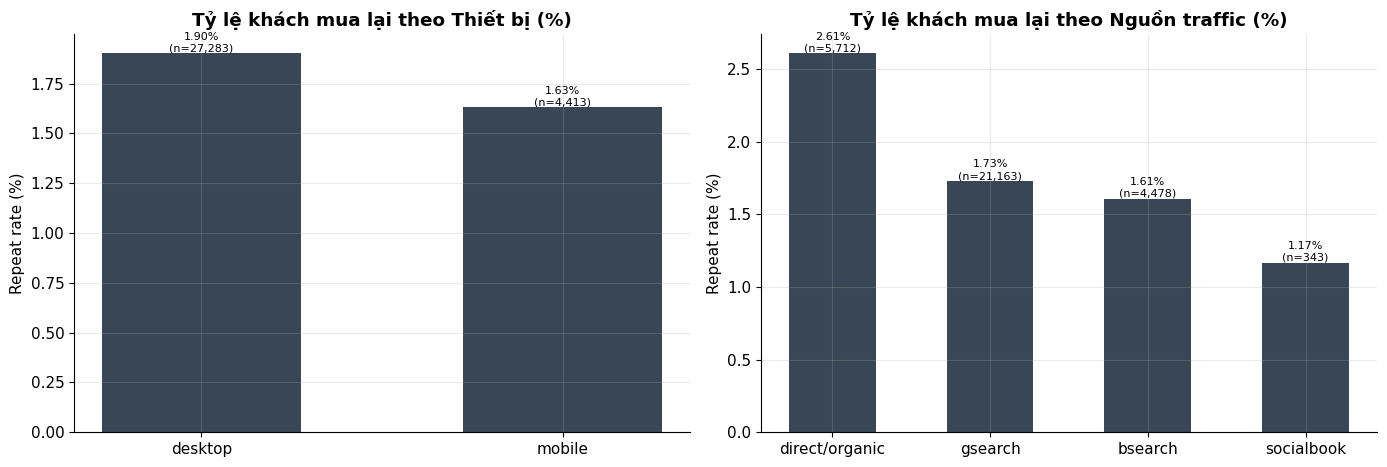

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, d, title in [(axes[0], ret_device, 'theo Thiết bị'),
                     (axes[1], ret_source, 'theo Nguồn traffic')]:
    bars = ax.bar(d.iloc[:, 0], d['repeat_rate'], color=NAVY, width=0.55)
    ax.set_title(f'Tỷ lệ khách mua lại {title} (%)', fontweight='bold')
    ax.set_ylabel('Repeat rate (%)')
    for b, r, n in zip(bars, d['repeat_rate'], d['n_customers']):
        ax.text(b.get_x() + b.get_width()/2, r, f'{r:.2f}%\n(n={n:,})',
                ha='center', va='bottom', fontsize=8)
save('06b_repeat_rate_drilldown')

In [ ]:
repeat_rate = (o.groupby('user_id')['order_id'].nunique() > 1).mean() * 100
avg_orders  = o.groupby('user_id')['order_id'].nunique().mean()

print(f'Tỷ lệ khách mua lại (≥2 đơn) : {repeat_rate:.2f}%')
print(f'Số đơn trung bình / khách    : {avg_orders:.2f}')
print(f'Retention trung bình tháng 1 : {retention_matrix[1].mean()*100:.2f}%')
print(f'Retention trung bình tháng 3 : {retention_matrix[3].mean()*100:.2f}%')
print(f'Doanh thu TB / khách         : ${o.groupby("user_id")["price_usd"].sum().mean():,.2f}')

Tỷ lệ khách mua lại (≥2 đơn) : 1.86%
Số đơn trung bình / khách    : 1.02
Retention trung bình tháng 1 : 0.84%
Retention trung bình tháng 3 : 0.20%
Doanh thu TB / khách         : $61.16


#3.Chuyển đổi & Hành vi (Funnel & Basket)

##3.1. Phân phối Traffic theo Nguồn & Thiết bị

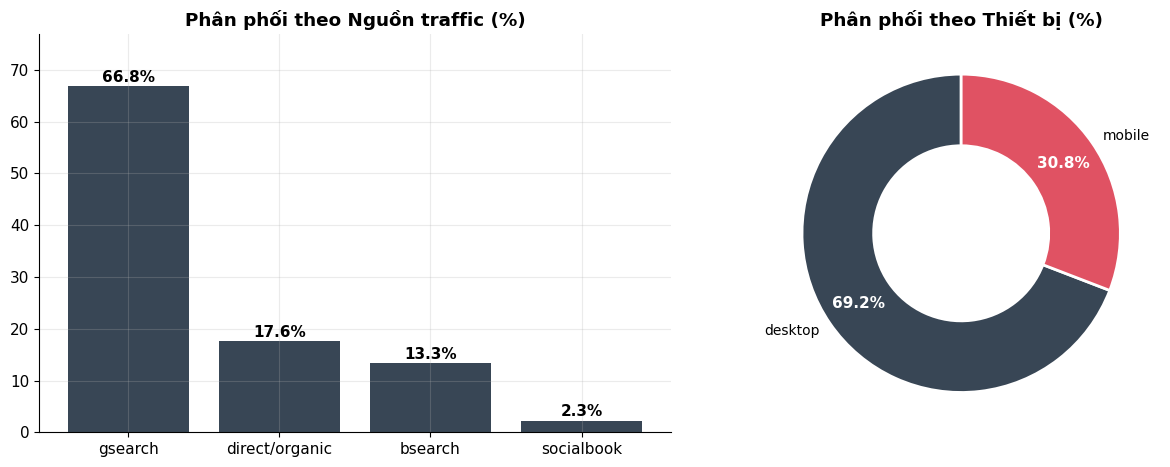

In [ ]:
source_dist = (website_sessions['utm_source'].value_counts(normalize=True)
               .mul(100).reset_index())
device_dist = (website_sessions['device_type'].value_counts(normalize=True)
               .mul(100).reset_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].bar(source_dist['utm_source'], source_dist['proportion'], color=NAVY)
axes[0].set_title('Phân phối theo Nguồn traffic (%)', fontweight='bold')
axes[0].set_ylim(0, source_dist['proportion'].max() * 1.15)
for i, v in enumerate(source_dist['proportion']):
    axes[0].text(i, v + 0.8, f'{v:.1f}%', ha='center', fontweight='bold')

wedges, texts, autotexts = axes[1].pie(
    device_dist['proportion'],
    labels=device_dist['device_type'],
    colors=[NAVY, RED],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2),
    pctdistance=0.78,        # chính giữa vành donut
    labeldistance=1.08,
)

for t in autotexts:
    t.set_color('white')
    t.set_fontweight('bold')
    t.set_fontsize(11)
for t in texts:
    t.set_fontsize(10)

axes[1].set_title('Phân phối theo Thiết bị (%)', fontweight='bold')
save('07_traffic_distribution')

##3.2. Hành trình khách hàng - Sankey đa tầng

In [ ]:
# Bước 1: Xác định landing page của mỗi session
landing = (website_pageviews
           .sort_values(['website_session_id', 'created_at'])
           .groupby('website_session_id', as_index=False)
           .first()[['website_session_id', 'pageview_url']]
           .rename(columns={'pageview_url': 'landing_page'}))

# Bước 2: Hợp nhất session + đơn hàng + sản phẩm chính
journey = (website_sessions[['website_session_id', 'created_at', 'month',
                             'utm_source', 'device_type']]
           .merge(landing, on='website_session_id', how='left')
           .merge(orders[['website_session_id', 'order_id', 'primary_product_id',
                          'price_usd', 'items_purchased']],
                  on='website_session_id', how='left')
           .merge(products[['product_id', 'product_name']],
                  left_on='primary_product_id', right_on='product_id', how='left'))

# Kiểm tra fan-out (pattern từ BTVN4)
n_sessions = website_sessions['website_session_id'].nunique()
assert len(journey) == n_sessions, \
    f'Fan-out sau merge: {n_sessions:,} session -> {len(journey):,} dòng'
print(f'Merge OK, số dòng khớp số session: {len(journey):,}')

# Bước 3: Xử lý khách thoát
journey['is_converted'] = journey['order_id'].notna()
journey['product_name'] = journey['product_name'].fillna('None (Drop-off)')

print(f'Tổng session: {len(journey):,} | Chuyển đổi: {journey["is_converted"].sum():,} '
      f'({journey["is_converted"].mean()*100:.2f}%)')
journey.head(3)

Merge OK, số dòng khớp số session: 472,871
Tổng session: 472,871 | Chuyển đổi: 32,313 (6.83%)


,website_session_id,created_at,month,utm_source,device_type,landing_page,order_id,primary_product_id,price_usd,items_purchased,product_id,product_name,is_converted
0,1,2012-03-19 08:04:16,2012-03-01,gsearch,mobile,/home,NaN,NaN,NaN,NaN,NaN,None (Drop-off),False
1,2,2012-03-19 08:16:49,2012-03-01,gsearch,desktop,/home,NaN,NaN,NaN,NaN,NaN,None (Drop-off),False
2,3,2012-03-19 08:26:55,2012-03-01,gsearch,desktop,/home,NaN,NaN,NaN,NaN,NaN,None (Drop-off),False


In [ ]:
# Bước 4: Cấu trúc 2 tầng (utm_source -> landing_page -> product)
l1 = journey.groupby(['utm_source', 'landing_page']).size().reset_index(name='value')
l1.columns = ['source', 'target', 'value']
l2 = journey.groupby(['landing_page', 'product_name']).size().reset_index(name='value')
l2.columns = ['source', 'target', 'value']
sankey_data = pd.concat([l1, l2], ignore_index=True)

all_nodes  = list(pd.concat([sankey_data['source'], sankey_data['target']]).unique())
node_map   = {n: i for i, n in enumerate(all_nodes)}
node_colors = [RED if n == 'None (Drop-off)' else NAVY for n in all_nodes]

fig = go.Figure(go.Sankey(
    node=dict(pad=15, thickness=20, line=dict(color='white', width=0.5),
              label=all_nodes, color=node_colors),
    link=dict(source=sankey_data['source'].map(node_map),
              target=sankey_data['target'].map(node_map),
              value=sankey_data['value'], color='rgba(56,70,85,0.18)')
))
fig.update_layout(title_text='Hành trình khách hàng: Nguồn → Landing Page → Sản phẩm')
fig.show()

save_plotly(fig, '08_sankey_journey')


PNG lỗi (ValueError) — đã lưu 08_sankey_journey.html


In [ ]:
# Landing page nào hút traffic nhưng drop-off cao?
lander = journey.groupby('landing_page').agg(
    sessions=('website_session_id', 'count'), converted=('is_converted', 'sum')).reset_index()
lander['dropoff_pct'] = (1 - lander['converted'] / lander['sessions']) * 100
lander.sort_values('sessions', ascending=False)

,landing_page,sessions,converted,dropoff_pct
0,/home,137576,9711,92.94
2,/lander-2,131170,10128,92.28
3,/lander-3,79000,2679,96.61
5,/lander-5,68166,6930,89.83
1,/lander-1,47574,2157,95.47
4,/lander-4,9385,708,92.46


##3.3. Phễu chuyển đổi 7 bước theo Thiết bị

In [ ]:
STEP_URLS = {
    'Products'      : ['/products'],
    'Product Detail': ['/the-original-mr-fuzzy', '/the-forever-love-bear',
                       '/the-birthday-sugar-panda', '/the-hudson-river-mini-bear'],
    'Cart'          : ['/cart'],
    'Shipping'      : ['/shipping'],
    'Billing'       : ['/billing', '/billing-2'],
    'Thank you'     : ['/thank-you-for-your-order'],
}
STEPS = ['Landed'] + list(STEP_URLS.keys())

pv_unique = website_pageviews[['website_session_id', 'pageview_url']].drop_duplicates()

funnel_flags = website_sessions[['website_session_id', 'device_type',
                                 'utm_source', 'created_at', 'month']].copy()
funnel_flags['Landed'] = True
for step, urls in STEP_URLS.items():
    ids = set(pv_unique.loc[pv_unique['pageview_url'].isin(urls), 'website_session_id'])
    funnel_flags[step] = funnel_flags['website_session_id'].isin(ids)

funnel_flags[STEPS].sum()

,0
Landed,472871
Products,261231
Product Detail,210214
Cart,94953
Shipping,64484
Billing,52058
Thank you,32313


In [ ]:
def build_funnel(df, label):
    counts = [int(df[s].sum()) for s in STEPS]
    out = pd.DataFrame({'Step': STEPS, 'Sessions': counts})
    out['CTR_prev (%)']  = out['Sessions'] / out['Sessions'].shift(1) * 100
    out.loc[0, 'CTR_prev (%)'] = 100
    out['Drop-off (%)']  = 100 - out['CTR_prev (%)']
    out['CR_total (%)']  = out['Sessions'] / out['Sessions'].iloc[0] * 100
    out['Device'] = label
    return out

funnel_desktop = build_funnel(funnel_flags[funnel_flags['device_type'] == 'desktop'], 'Desktop')
funnel_mobile  = build_funnel(funnel_flags[funnel_flags['device_type'] == 'mobile'],  'Mobile')
funnel_all = pd.concat([funnel_desktop, funnel_mobile], ignore_index=True)
funnel_all

,Step,Sessions,CTR_prev (%),Drop-off (%),CR_total (%),Device
0,Landed,327027,100.00,0.00,100.00,Desktop
1,Products,192325,58.81,41.19,58.81,Desktop
2,Product Detail,163214,84.86,15.14,49.91,Desktop
3,Cart,75155,46.05,53.95,22.98,Desktop
4,Shipping,52692,70.11,29.89,16.11,Desktop
5,Billing,43722,82.98,17.02,13.37,Desktop
6,Thank you,27805,63.59,36.41,8.50,Desktop
7,Landed,145844,100.00,0.00,100.00,Mobile
8,Products,68906,47.25,52.75,47.25,Mobile
9,Product Detail,47000,68.21,31.79,32.23,Mobile


In [ ]:
fig = make_subplots(rows=1, cols=2, specs=[[{'type': 'funnel'}, {'type': 'funnel'}]],
                    subplot_titles=('Funnel: DESKTOP', 'Funnel: MOBILE'))
fig.add_trace(go.Funnel(name='Desktop', y=funnel_desktop['Step'], x=funnel_desktop['Sessions'],
                        textinfo='value+percent initial+percent previous',
                        marker={'color': NAVY}), row=1, col=1)
fig.add_trace(go.Funnel(name='Mobile', y=funnel_mobile['Step'], x=funnel_mobile['Sessions'],
                        textinfo='value+percent initial+percent previous',
                        marker={'color': RED}), row=1, col=2)
fig.update_layout(title_text='Phễu chuyển đổi 7 bước: Desktop vs Mobile')
fig.show()

save_plotly(fig, '09_funnel_device')


PNG lỗi (ValueError) — đã lưu 09_funnel_device.html


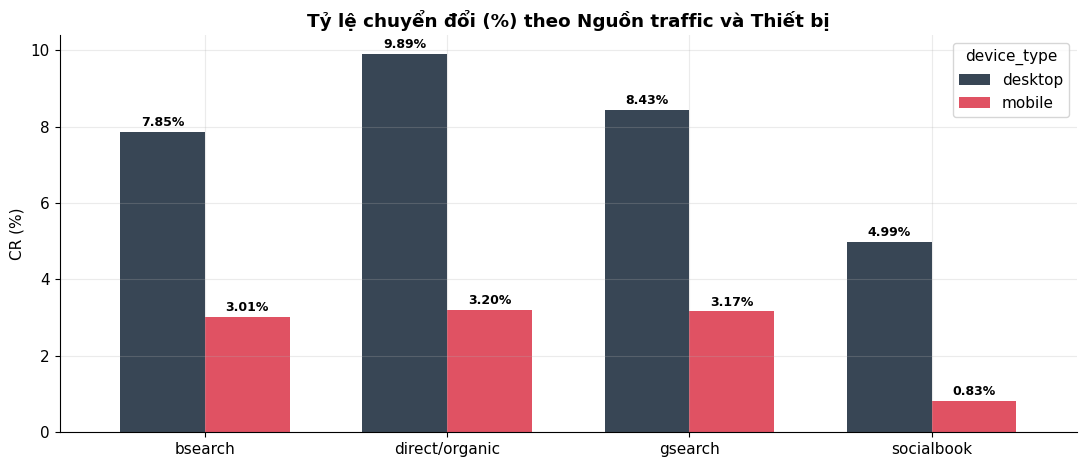

In [ ]:
# CR tổng thể theo Nguồn × Thiết bị
cr_matrix = (funnel_flags.groupby(['utm_source', 'device_type'])
             .agg(sessions=('website_session_id', 'count'), orders=('Thank you', 'sum'))
             .reset_index())
cr_matrix['CR (%)'] = cr_matrix['orders'] / cr_matrix['sessions'] * 100
cr_pivot = cr_matrix.pivot(index='utm_source', columns='device_type', values='CR (%)')

ax = cr_pivot.plot(kind='bar', color=[NAVY, RED], figsize=(11, 4.8), rot=0, width=0.7)
ax.set_title('Tỷ lệ chuyển đổi (%) theo Nguồn traffic và Thiết bị', fontweight='bold')
ax.set_ylabel('CR (%)'); ax.set_xlabel('')
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f%%', fontsize=9, padding=2, fontweight='bold')
save('10_cr_source_device')

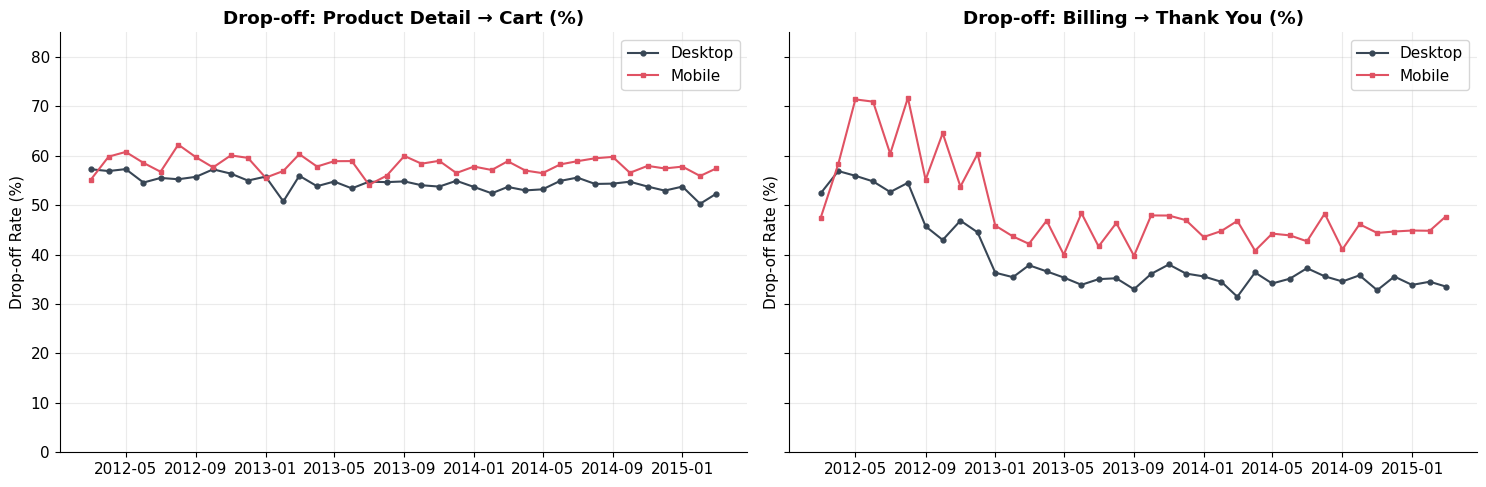

In [ ]:
# Xu hướng drop-off theo tháng tại 2 nút thắt chính
trend = (funnel_flags.groupby(['month', 'device_type'])
         .agg(detail=('Product Detail', 'sum'), cart=('Cart', 'sum'),
              billing=('Billing', 'sum'), thankyou=('Thank you', 'sum'))
         .reset_index())
trend['drop_detail_cart']  = (1 - trend['cart'] / trend['detail']) * 100
trend['drop_billing_order'] = (1 - trend['thankyou'] / trend['billing']) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, col, title in zip(axes,
        ['drop_detail_cart', 'drop_billing_order'],
        ['Product Detail → Cart', 'Billing → Thank You']):
    for dev, color, mk in [('desktop', NAVY, 'o'), ('mobile', RED, 's')]:
        sub = trend[trend['device_type'] == dev]
        ax.plot(sub['month'], sub[col], color=color, marker=mk, ms=3.5, label=dev.capitalize())
    ax.set_title(f'Drop-off: {title} (%)', fontweight='bold')
    ax.set_ylabel('Drop-off Rate (%)'); ax.set_ylim(0, 85); ax.legend()
save('11_dropoff_trend')

In [ ]:
# Phễu theo sản phẩm
PRODUCT_URLS = {
    'The Original Mr. Fuzzy'      : '/the-original-mr-fuzzy',
    'The Forever Love Bear'       : '/the-forever-love-bear',
    'The Birthday Sugar Panda'    : '/the-birthday-sugar-panda',
    'The Hudson River Mini bear'  : '/the-hudson-river-mini-bear',
}

rows = []
sess_products = set(pv_unique.loc[pv_unique['pageview_url'] == '/products', 'website_session_id'])
for name, url in PRODUCT_URLS.items():
    detail = set(pv_unique.loc[pv_unique['pageview_url'] == url, 'website_session_id']) & sess_products
    cart   = detail & set(pv_unique.loc[pv_unique['pageview_url'] == '/cart', 'website_session_id'])
    order  = detail & set(pv_unique.loc[pv_unique['pageview_url'] == '/thank-you-for-your-order', 'website_session_id'])
    rows.append({'product_name': name,
                 'products': len(sess_products), 'detail': len(detail),
                 'cart': len(cart), 'order': len(order)})

prod_funnel = pd.DataFrame(rows)
prod_funnel['CTR_products_detail'] = prod_funnel['detail'] / prod_funnel['products'] * 100
prod_funnel['CTR_detail_cart']     = prod_funnel['cart'] / prod_funnel['detail'] * 100
prod_funnel['CTR_cart_order']      = prod_funnel['order'] / prod_funnel['cart'] * 100
prod_funnel

,product_name,products,detail,cart,order,CTR_products_detail,CTR_detail_cart,CTR_cart_order
0,The Original Mr. Fuzzy,261231,162525,69957,23861,62.22,43.04,34.11
1,The Forever Love Bear,261231,26033,14485,4803,9.97,55.64,33.16
2,The Birthday Sugar Panda,261231,19046,8811,3068,7.29,46.26,34.82
3,The Hudson River Mini bear,261231,2610,1700,581,1.00,65.13,34.18


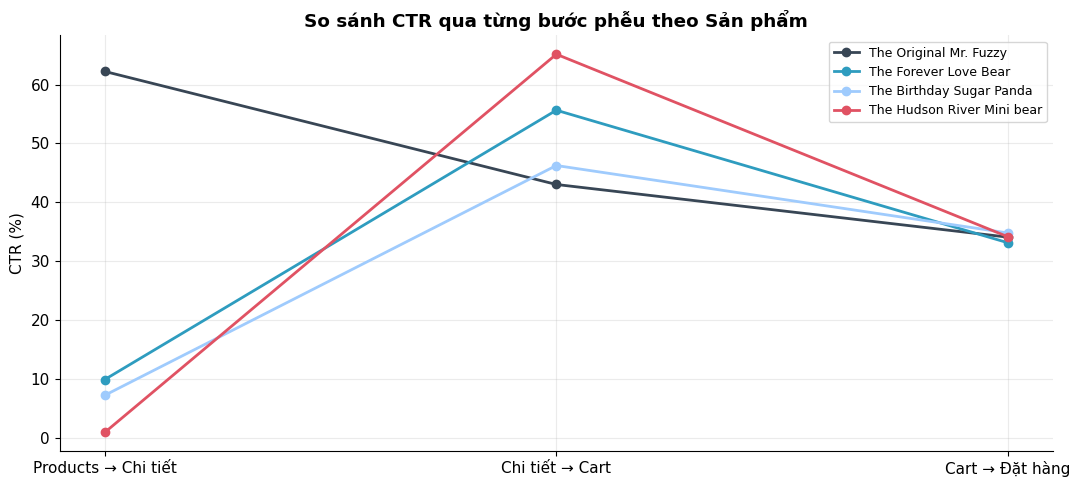

In [ ]:
steps = ['CTR_products_detail', 'CTR_detail_cart', 'CTR_cart_order']
labels = ['Products → Chi tiết', 'Chi tiết → Cart', 'Cart → Đặt hàng']

plt.figure(figsize=(11, 5))
for (_, row), color in zip(prod_funnel.iterrows(), PALETTE):
    plt.plot(labels, [row[s] for s in steps], marker='o', lw=2,
             label=row['product_name'], color=color)
plt.ylabel('CTR (%)')
plt.title('So sánh CTR qua từng bước phễu theo Sản phẩm', fontweight='bold')
plt.legend(fontsize=9)
save('11b_funnel_by_product')

##3.4. AOV & Market Basket Analysis

In [ ]:
orders['order_type'] = np.where(orders['items_purchased'] > 1, 'Cross-sell', 'Single')

aov_data = orders.groupby('order_type').agg(
    n_orders=('order_id', 'count'), revenue=('price_usd', 'sum')).reset_index()
aov_data['aov']            = aov_data['revenue'] / aov_data['n_orders']
aov_data['order_share_pct'] = aov_data['n_orders'] / aov_data['n_orders'].sum() * 100
aov_data['rev_share_pct']   = aov_data['revenue'] / aov_data['revenue'].sum() * 100
aov_data

,order_type,n_orders,revenue,aov,order_share_pct,rev_share_pct
0,Cross-sell,7712,"688,301.76",89.25,23.87,35.51
1,Single,24601,"1,250,207.99",50.82,76.13,64.49


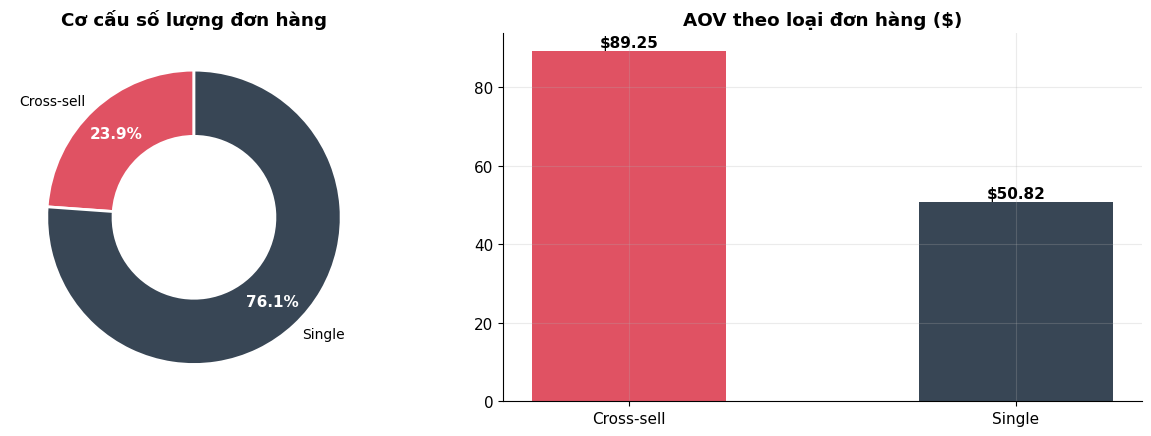

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

wedges, texts, autotexts = axes[0].pie(
    aov_data['n_orders'],
    labels=aov_data['order_type'],
    colors=[RED, NAVY],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2),
    pctdistance=0.78,        # 0.78 = chính giữa vành donut (bán kính 0.55 → 1.0)
    labeldistance=1.08,      # đẩy nhãn ra ngoài, tránh chạm vành
)

for t in autotexts:
    t.set_color('white')
    t.set_fontweight('bold')
    t.set_fontsize(11)

for t in texts:
    t.set_fontsize(10)

axes[0].set_title('Cơ cấu số lượng đơn hàng', fontweight='bold')

axes[1].bar(aov_data['order_type'], aov_data['aov'], color=[RED, NAVY], width=0.5)
axes[1].set_title('AOV theo loại đơn hàng ($)', fontweight='bold')
for i, v in enumerate(aov_data['aov']):
    axes[1].text(i, v + 1, f'${v:.2f}', ha='center', fontweight='bold')

save('12_aov_crosssell')

In [ ]:
# Market Basket: Support / Confidence / Lift
df_mba = oi_base.merge(oi_base, on='order_id', suffixes=('_A', '_B'))
df_mba = df_mba[df_mba['product_id_A'] != df_mba['product_id_B']]

pair = df_mba.groupby(['product_name_A', 'product_name_B'], as_index=False).agg(
    orders_AB=('order_id', 'nunique'))

n_total = oi_base['order_id'].nunique()
freq = oi_base.groupby('product_name')['order_id'].nunique().reset_index(name='orders_x')

pair = (pair.merge(freq.rename(columns={'product_name': 'product_name_A', 'orders_x': 'orders_A'}),
                   on='product_name_A')
            .merge(freq.rename(columns={'product_name': 'product_name_B', 'orders_x': 'orders_B'}),
                   on='product_name_B'))

pair['support_pct']    = pair['orders_AB'] / n_total * 100
pair['confidence_pct'] = pair['orders_AB'] / pair['orders_A'] * 100
pair['lift']           = pair['confidence_pct'] / (pair['orders_B'] / n_total * 100)
pair['combo'] = pair['product_name_A'].str.replace('The ', '') + ' + ' + \
                pair['product_name_B'].str.replace('The ', '')

# Dedup cặp đối xứng (pattern get_pair_key + drop_duplicates của BTVN7)
# Lift(A->B) == Lift(B->A) nên nếu không dedup, biểu đồ Top Lift sẽ hiện mỗi cặp 2 lần.
# Confidence thì KHÔNG đối xứng nên giữ nguyên đủ 2 chiều ở bảng `pair`.
pair['pair_key'] = pair.apply(
    lambda r: tuple(sorted([r['product_name_A'], r['product_name_B']])), axis=1)
pair_lift = pair.drop_duplicates(subset='pair_key').copy()

print(f'Số rule có thứ tự: {len(pair)}  ->  số cặp duy nhất: {len(pair_lift)}')
pair_lift.sort_values('lift', ascending=False)[
    ['combo', 'orders_AB', 'support_pct', 'confidence_pct', 'lift']]


Số rule có thứ tự: 12  ->  số cặp duy nhất: 6


,combo,orders_AB,support_pct,confidence_pct,lift
1,Birthday Sugar Panda + Hudson River Mini bear,662,2.05,13.28,0.86
8,Hudson River Mini bear + Original Mr. Fuzzy,3142,9.72,62.61,0.84
4,Forever Love Bear + Hudson River Mini bear,680,2.10,11.73,0.76
2,Birthday Sugar Panda + Original Mr. Fuzzy,2036,6.30,40.84,0.54
0,Birthday Sugar Panda + Forever Love Bear,248,0.77,4.97,0.28
5,Forever Love Bear + Original Mr. Fuzzy,944,2.92,16.29,0.22


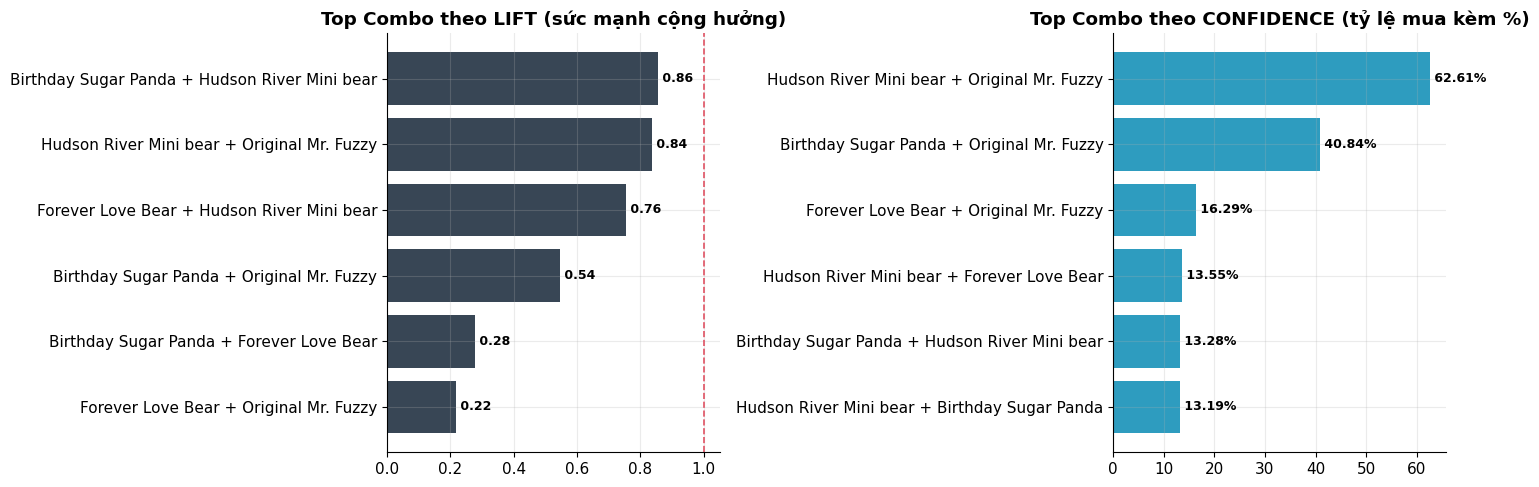

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

top_lift = pair_lift.sort_values('lift', ascending=False).head(6).iloc[::-1]
axes[0].barh(top_lift['combo'], top_lift['lift'], color=NAVY)
axes[0].axvline(1, color=RED, ls='--', lw=1.2)
axes[0].set_title('Top Combo theo LIFT (sức mạnh cộng hưởng)', fontweight='bold')
for i, v in enumerate(top_lift['lift']):
    axes[0].text(v, i, f' {v:.2f}', va='center', fontsize=9, fontweight='bold')

top_conf = pair.sort_values('confidence_pct', ascending=False).head(6).iloc[::-1]
axes[1].barh(top_conf['combo'], top_conf['confidence_pct'], color=TEAL)
axes[1].set_title('Top Combo theo CONFIDENCE (tỷ lệ mua kèm %)', fontweight='bold')
for i, v in enumerate(top_conf['confidence_pct']):
    axes[1].text(v, i, f' {v:.2f}%', va='center', fontsize=9, fontweight='bold')

save('13_basket_lift_confidence')

#4.Chất lượng & Vận hành (Refund Analysis)

##4.1. Tỷ lệ hoàn hàng theo sản phẩm và theo thời gian

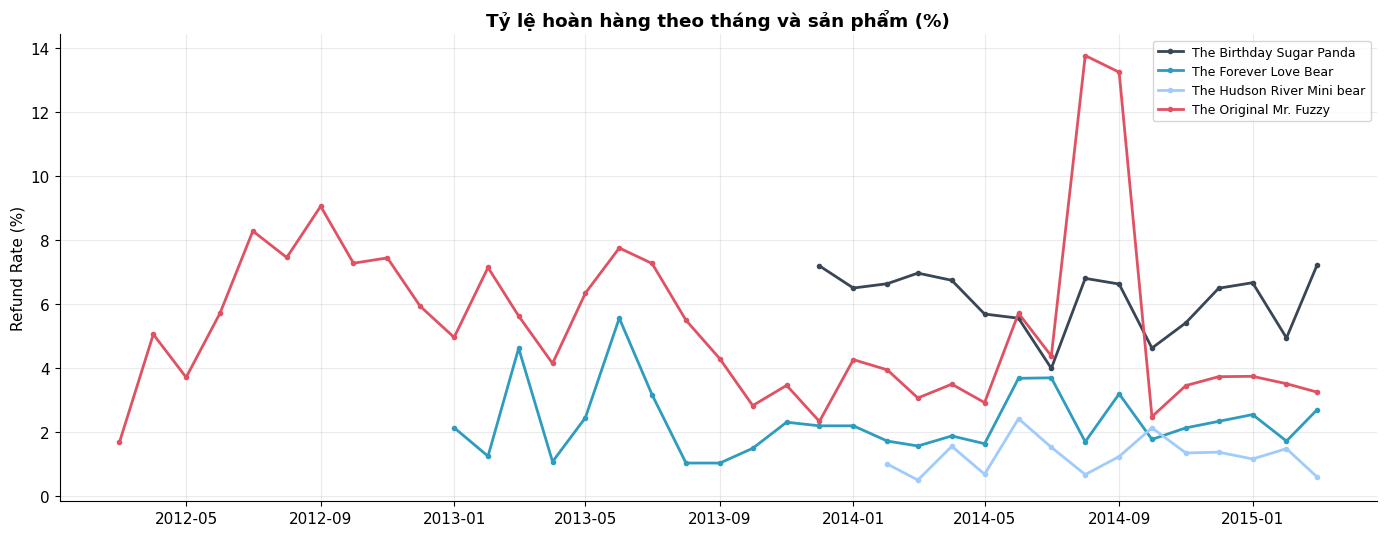

In [ ]:
refund_ts = oi.groupby(['month', 'product_name']).agg(
    items=('order_item_id', 'count'),
    refunded=('is_refunded', 'sum'),
    refund_amount=('refund_amount_usd', 'sum'),
).reset_index()
refund_ts['refund_rate'] = refund_ts['refunded'] / refund_ts['items'] * 100

plt.figure(figsize=(14, 5.5))
for (name, g), color in zip(refund_ts.groupby('product_name'), PALETTE):
    plt.plot(g['month'], g['refund_rate'], marker='o', ms=3, lw=2, label=name, color=color)
plt.title('Tỷ lệ hoàn hàng theo tháng và sản phẩm (%)', fontweight='bold')
plt.ylabel('Refund Rate (%)'); plt.legend(fontsize=9)
save('14_refund_trend')

##4.2. Quy luật mùa vụ của tỷ lệ hoàn hàng

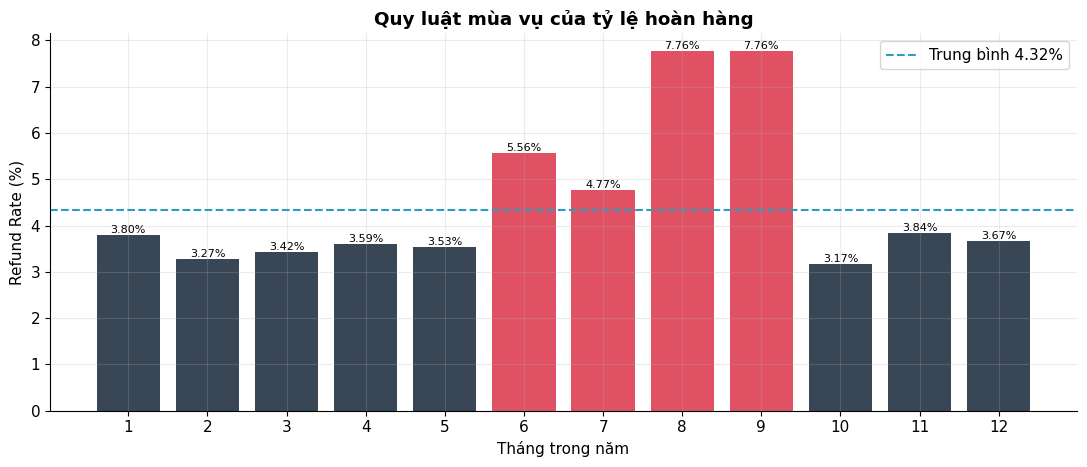

In [ ]:
seasonal = oi.copy()
seasonal['month_of_year'] = seasonal['created_at'].dt.month
s = seasonal.groupby('month_of_year').agg(
    items=('order_item_id', 'count'), refunded=('is_refunded', 'sum')).reset_index()
s['refund_rate'] = s['refunded'] / s['items'] * 100
avg_rate = oi['is_refunded'].mean() * 100

plt.figure(figsize=(11, 4.8))
bars = plt.bar(s['month_of_year'], s['refund_rate'],
               color=[RED if v > avg_rate else NAVY for v in s['refund_rate']])
plt.axhline(avg_rate, color=TEAL, ls='--', lw=1.5, label=f'Trung bình {avg_rate:.2f}%')
plt.xticks(range(1, 13)); plt.xlabel('Tháng trong năm'); plt.ylabel('Refund Rate (%)')
plt.title('Quy luật mùa vụ của tỷ lệ hoàn hàng', fontweight='bold'); plt.legend()
for b, v in zip(bars, s['refund_rate']):
    plt.text(b.get_x() + b.get_width()/2, v + 0.05, f'{v:.2f}%', ha='center', fontsize=8)
save('15_refund_seasonality')

In [ ]:
# Thiệt hại tài chính do hoàn hàng, theo sản phẩm
loss = product_perf[['product_name', 'total_refund', 'refund_rate_pct', 'net_profit']].copy()
loss['refund_as_pct_of_profit'] = loss['total_refund'] / loss['net_profit'] * 100
loss.sort_values('total_refund', ascending=False)

,product_name,total_refund,refund_rate_pct,net_profit,refund_as_pct_of_profit
0,The Original Mr. Fuzzy,"61,837.63",5.11,"677,055.37",9.13
2,The Birthday Sugar Panda,"13,842.99",6.04,"143,184.51",9.67
1,The Forever Love Bear,"7,738.71",2.23,"209,611.29",3.69
3,The Hudson River Mini bear,"1,919.36",1.28,"100,949.64",1.90


In [ ]:
def show(title, obj):
    print('=' * 70); print(title); print('=' * 70)
    print(obj.to_string(index=False) if isinstance(obj, pd.DataFrame) else obj.to_string())
    print()

show('CR (%) THEO NGUỒN × THIẾT BỊ', cr_pivot)
show('REFUND RATE THEO THÁNG TRONG NĂM', s)
show('DROP-OFF THEO THÁNG (6 tháng cuối)', trend.tail(12))

CR (%) THEO NGUỒN × THIẾT BỊ
 desktop  mobile
    7.85    3.01
    9.89    3.20
    8.43    3.17
    4.99    0.83

REFUND RATE THEO THÁNG TRONG NĂM
 month_of_year  items  refunded  refund_rate
             1   4347       165         3.80
             2   4552       149         3.27
             3   3565       122         3.42
             4   2309        83         3.59
             5   2552        90         3.53
             6   2408       134         5.56
             7   2518       120         4.77
             8   2628       204         7.76
             9   2873       223         7.76
            10   3311       105         3.17
            11   4218       162         3.84
            12   4744       174         3.67

DROP-OFF THEO THÁNG (6 tháng cuối)
     month device_type  detail  cart  billing  thankyou  drop_detail_cart  drop_billing_order
2014-10-01     desktop    7861  3556     2147      1378             54.76               35.82
2014-10-01      mobile    2374  1031      4

#Nhận xét

## Nhận xét Phần 1

### 1.1. Doanh thu gộp che giấu cấu trúc lợi nhuận thật

- Doanh thu gộp đạt **\$1,938,509.75**, nhưng sau khi trừ giá vốn (**\$722,370.25**, chiếm 37.26% doanh thu) và hoàn tiền (**\$85,338.69**, chiếm 4.40%), lợi nhuận ròng chỉ còn **\$1,130,800.81** — biên ròng **58.33%**.
- Riêng khoản hoàn tiền đã ăn mất 4.4% doanh thu, tương đương gần **7.5%** lợi nhuận ròng của cả doanh nghiệp.

### 1.2. Nghịch lý sản phẩm chủ lực

| Sản phẩm | Doanh thu | %DT | Biên ròng | Refund rate |
|---|---|---|---|---|
| The Original Mr. Fuzzy | \$1,211,058 | 62.47% | **55.91%** | 5.11% |
| The Forever Love Bear | \$347,702 | 17.94% | 60.28% | 2.23% |
| The Birthday Sugar Panda | \$229,260 | 11.83% | 62.46% | **6.04%** |
| The Hudson River Mini bear | \$150,490 | 7.76% | **67.08%** | **1.28%** |

- **Bán nhiều nhất lại lãi ít nhất:** `Mr. Fuzzy` chiếm 62.47% doanh thu nhưng có biên ròng **thấp nhất (55.91%)**, thua `Hudson River Mini bear` tới **11.17 điểm %**.
  + Nguyên nhân: giá vốn cao (38.99% doanh thu) cộng 1,237 đơn hoàn tiền, làm mất **\$61,837.63**.
- **Phát hiện ngoài dự đoán:** sản phẩm có tỷ lệ hoàn hàng cao nhất **không phải** Mr. Fuzzy mà là `Birthday Sugar Panda` (**6.04%**). Do quy mô nhỏ hơn nên con số tuyệt đối ít nổi bật, nhưng xét tương quan, khoản hoàn tiền của Panda ăn mất **9.67%** lợi nhuận của chính nó — cao nhất toàn danh mục.
- **Sản phẩm bị đánh giá thấp:** `Hudson River Mini bear` vừa có biên ròng cao nhất (67.08%) vừa có tỷ lệ hoàn hàng thấp nhất (1.28%), nhưng chỉ đóng góp 7.76% doanh thu. Đây là dòng sản phẩm chất lượng nhất về kinh tế đơn vị mà lại đang được khai thác ít nhất.

### 1.3. Pareto & ABC: hai bức tranh trái ngược

**Ở tầng sản phẩm — tập trung rủi ro rất cao:**
- 2/4 sản phẩm (Mr. Fuzzy + Love Bear) thuộc nhóm **A**, đã tạo **78.41%** lợi nhuận. Riêng Mr. Fuzzy chiếm 59.87%.
- Với danh mục chỉ 4 SKU, quy luật 80/20 không bộc lộ đầy đủ như tập dữ liệu hàng trăm mã. Tuy vậy kết luận vẫn rõ: doanh nghiệp phụ thuộc gần như hoàn toàn vào một sản phẩm duy nhất — nếu Mr. Fuzzy gặp vấn đề chất lượng hoặc bị đối thủ sao chép, hơn nửa lợi nhuận có thể sẽ biến mất.

**Ở tầng nguồn traffic — cũng tập trung vào 1 nguồn:**
- `gsearch` một mình mang về **\$1,276,145** (65.83% doanh thu). Cùng `direct/organic`, hai nguồn này chiếm **84.99%**.
- `socialbook` chỉ đóng góp **\$22,259** (1.15%) — gần như không đáng kể.

**Ở tầng khách hàng — hoàn toàn KHÔNG tuân theo Pareto:**
- Nhóm A cần tới **23,581 khách (74.40%)** mới đạt 80% doanh thu. Đây là điều rất bất thường: ở một doanh nghiệp bán lẻ khỏe mạnh, con số này thường dưới 20%.
- Nguyên nhân: hầu như mọi khách chỉ mua đúng **một** đơn, nên giá trị khách gần như bằng nhau. Không có "khách VIP" nào để tập trung chăm sóc.
- **Hàm ý:** mọi chiến lược loyalty theo kiểu "dồn nguồn lực vào top 20% khách hàng" đều không áp dụng được ở đây. Vấn đề không nằm ở việc chọn đúng khách, mà ở chỗ chưa có khách nào quay lại.

## Nhận xét Phần 2

### 2.1. Doanh nghiệp gần như không có vòng đời khách hàng

- Trong **31,696** khách hàng, có **31,105 người (98.14%) chỉ mua đúng 1 lần**. Chỉ 565 khách mua 2 đơn và 26 khách mua 3 đơn — mức tối đa trong toàn bộ 3 năm dữ liệu.
- Tỷ lệ khách mua lại: **1.86%**. Số đơn trung bình mỗi khách: **1.02**. Doanh thu trung bình mỗi khách: **\$61.16** — gần như bằng đúng AOV (\$59.99).
- Retention trung bình tháng thứ 1 chỉ **0.84%**, tháng thứ 3 còn **0.20%**. Heatmap cohort gần như trắng hoàn toàn từ cột thứ hai trở đi.

**Đây không phải lỗi dữ liệu mà là phát hiện quan trọng nhất của toàn báo cáo**. Tiền quảng cáo chi ra chỉ thu hồi được qua đúng một đơn hàng, vì không có đơn thứ hai. Doanh nghiệp phải liên tục mua khách mới để giữ doanh thu — chi phí này không bao giờ giảm dù kinh doanh đến bao lâu chăng nữa.

### 2.2. Về kết quả phân khúc RFM cần lưu ý

- Cột `frequency` chỉ có **3 giá trị duy nhất** (1, 2, 3), khiến `qcut` thô chỉ tạo được **1 nhóm**. Hàm `dedupe_qcut_score()` chấm điểm trên giá trị duy nhất nên vẫn phân tách được, nhưng thang F thực chất chỉ có 3 bậc thay vì 5.
  + Hệ quả: phân bố segment bị lệch nặng về các nhóm F thấp. **Promising** chiếm tới **15,928 khách (50.25%)**, còn **Champions chỉ có 14 người (0.04%)**.
- Vì vậy tên gọi các segment ở đây phản ánh chủ yếu **Recency và Monetary**, không phải mức độ trung thành thực sự.

**Dù vậy, vẫn có 2 điểm dùng được:**
- Nhóm **Champions** (14 khách) có doanh thu bình quân **\$188.25/khách** — gấp **hơn 3 lần** mức trung bình toàn hệ thống (\$61.16). Nhóm **Loyal** (245 khách) đạt \$134.24, **Need Attention** (160 khách) đạt \$122.89. Khách nào mua lần thứ hai đều tạo giá trị vượt trội rõ rệt.
- Nhóm **Lost customers** có tới **5,620 khách (17.73%)** với recency trung bình **784 ngày** — hơn 2 năm không quay lại. Đây là tệp đã mất hẳn, không nên tốn ngân sách remarketing.

### 2.3. Chất lượng khách khác nhau theo kênh và thiết bị

| Chiều | Nhóm | Repeat rate |
|---|---|---|
| Nguồn | direct/organic | **2.61%** |
| Nguồn | gsearch | 1.73% |
| Nguồn | bsearch | 1.61% |
| Nguồn | socialbook | 1.17% |
| Thiết bị | desktop | 1.90% |
| Thiết bị | mobile | 1.63% |

- **Khách tự tìm đến là khách tốt nhất:** nhóm `direct/organic` có tỷ lệ mua lại **2.61%** — cứ 100 khách thì gần 3 người quay lại, so với chỉ 1–2 người ở các kênh quảng cáo. Điều này hợp lý vì: người chủ động gõ tên website hoặc tìm thấy qua kết quả tự nhiên vốn đã có nhu cầu thật, khác với người vô tình bấm vào một link quảng cáo.
- **`socialbook` yếu ở mọi mặt:** kênh này chỉ mang về 1.15% doanh thu, tỷ lệ mua lại thấp nhất (1.17%), và trên điện thoại thì gần như không bán được hàng (CR 0.83%). Khách từ đây vừa ít, vừa mua ít, vừa không quay lại.
- - **Khách trên mobile không kém chất lượng — họ chỉ khó mua hàng hơn.** Xét tỷ lệ mua lại, mobile (1.63%) chỉ thua desktop (1.90%) một chút. Nhưng xét tỷ lệ chuyển đổi, mobile (3.09%) thua desktop (8.50%) tới gần **3 lần**. Nếu khách mobile thực sự kém chất lượng thì cả hai chỉ số đều phải kém đều nhau. Khoảng cách chỉ giãn ra ở khâu mua hàng cho thấy vấn đề nằm ở giao diện website, không nằm ở khách.

## Nhận xét Phần 3

### 3.1. Khoảng cách trên Desktop – Mobile là vấn đề kỹ thuật, không phải chất lượng traffic

| Bước phễu | Desktop | Mobile | Chênh lệch |
|---|---|---|---|
| Landed | 327,027 | 145,844 | |
| → Products | 58.81% | 47.25% | −11.6 điểm |
| → Product Detail | 84.86% | 68.21% | −16.7 điểm |
| → Cart | 46.05% | 42.12% | −3.9 điểm |
| → Shipping | 70.11% | 59.56% | −10.6 điểm |
| → Billing | 82.98% | 70.69% | −12.3 điểm |
| → Thank you | 63.59% | 54.08% | −9.5 điểm |
| **CR tổng thể** | **8.50%** | **3.09%** | **2.75 lần** |

- Mobile **kém hơn ở toàn bộ 6 bước**, không tập trung ở một điểm nào. Nếu là vấn đề chất lượng traffic thì mức chênh sẽ khác nhau giữa các bước; việc khoảng cách xuất hiện đều đặn suốt phễu chỉ ra nguyên nhân nằm ở chính giao diện website.
- **Ước lượng thiệt hại:** nếu Mobile đạt được CR của Desktop, 145,844 phiên sẽ tạo ra **12,397 đơn** thay vì 4,508 đơn thực tế — thiếu hụt **7,889 đơn**, tương đương khoảng **\$473,000 doanh thu** bị bỏ lỡ trong 3 năm.
- Điểm gãy lớn nhất trên cả hai thiết bị đều là **Product Detail → Cart** (Desktop rơi 53.95%, Mobile rơi 57.88%). Đây là bước "quyết định mua", không phải bước kỹ thuật — cho thấy còn vấn đề về giá, phí ship hoặc sức thuyết phục của trang sản phẩm.
- Điểm gãy có chênh lệch thiết bị lớn nhất là **Billing → Thank you**: Mobile rơi **45.92%** so với Desktop **36.41%**. Gần một nửa khách mobile đã điền thông tin thanh toán rồi vẫn bỏ cuộc ở phút chót — dấu hiệu điển hình của form thanh toán không tương thích màn hình nhỏ.

**CR (%) theo Nguồn × Thiết bị:**

| Nguồn | Desktop | Mobile | Chênh lệch |
|---|---|---|---|
| direct/organic | **9.89%** | 3.20% | 3.09 lần |
| gsearch | 8.43% | 3.17% | 2.66 lần |
| bsearch | 7.85% | 3.01% | 2.61 lần |
| socialbook | 4.99% | **0.83%** | **6.01 lần** |

- **Khoảng cách xuất hiện ở cả 4 nguồn, không trừ nguồn nào** — đây là bằng chứng mạnh nhất cho kết luận rằng vấn đề nằm ở giao diện mobile chứ không phải chất lượng traffic.
- **`direct/organic` là nguồn tốt nhất về mọi mặt:** CR Desktop cao nhất (9.89%), CR Mobile cao nhất (3.20%), repeat rate cao nhất (2.61%). Đây là tệp khách chất lượng nhất nhưng chỉ chiếm 17.6% traffic.
- **`socialbook` gần như không chuyển đổi được trên Mobile:** CR chỉ **0.83%**, tức cứ 120 phiên mới có 1 đơn.
- Ngay cả `direct/organic` — nguồn tốt nhất — cũng chỉ đạt 3.20% trên Mobile, thấp hơn nguồn Desktop kém nhất (`socialbook` 4.99%). Nói cách khác: **traffic mobile tốt nhất vẫn thua traffic desktop tệ nhất.**

### 3.2. Landing page: `/lander-3` là điểm rò rỉ ngân sách rõ nhất

| Landing page | Sessions | Drop-off |
|---|---|---|
| /home | 137,576 | 92.94% |
| /lander-2 | 131,170 | 92.28% |
| **/lander-3** | **79,000** | **96.61%** |
| /lander-5 | 68,166 | **89.83%** |
| /lander-1 | 47,574 | 95.47% |
| /lander-4 | 9,385 | 92.46% |

- **`/lander-3` là trường hợp đáng lo nhất:** đứng thứ 3 về lưu lượng (79,000 phiên) nhưng drop-off **96.61%** — cao nhất toàn site. Nếu đưa được về mức của `/lander-5` (89.83%), riêng trang này đã tạo thêm khoảng **5,350 đơn**.
- **`/lander-5` là trang tốt nhất** (drop-off 89.83%) nhưng chỉ nhận 68,166 phiên. Nên phân tích thiết kế của trang này để áp dụng cho các trang còn lại, đồng thời chuyển bớt traffic sang đây.
- Cả 6 landing page đều có drop-off trên 89% — đây là vấn đề toàn hệ thống, không riêng trang nào.

### 3.3. Phễu theo sản phẩm: Hudson bị đặt ở vị trí ẩn nhạt hơn các sản phẩm khác, không phải bị chê

| Sản phẩm | Products → Chi tiết | Chi tiết → Cart | Cart → Đặt hàng |
|---|---|---|---|
| Mr. Fuzzy | **62.22%** | 43.04% | 34.11% |
| Forever Love Bear | 9.97% | 55.64% | 33.16% |
| Birthday Sugar Panda | 7.29% | 46.26% | 34.82% |
| Hudson River Mini bear | **1.00%** | **65.13%** | 34.18% |

Đây là phát hiện đáng giá nhất của Phần 3:

- `Hudson River Mini bear` chỉ được **1.00%** khách xem trang danh mục click vào — thấp hơn Mr. Fuzzy **62 lần**. Nhưng một khi đã xem chi tiết, **65.13%** khách thêm vào giỏ — **tỷ lệ cao nhất danh mục**, vượt Mr. Fuzzy (43.04%) tới 22 điểm phần trăm.
- Kết hợp với Phần 1 (Hudson có biên ròng cao nhất 67.08% và refund thấp nhất 1.28%), kết luận rất rõ: **đây không phải vấn đề sản phẩm kém hấp dẫn mà là vấn đề hiển thị**. Sản phẩm sinh lời tốt nhất, thuyết phục nhất lại đang bị ẩn ở vị trí không ai nhìn thấy.
- Bước `Cart → Đặt hàng` gần như đồng nhất ở cả 4 sản phẩm (33–35%), xác nhận rằng nút thắt thanh toán là vấn đề chung của hệ thống chứ không phụ thuộc sản phẩm.

### 3.4. Cross-sell hiệu quả, nhưng không đến từ mối liên kết sản phẩm

**Về AOV:**
- Đơn bán chéo có AOV **\$89.25**, cao hơn đơn đơn lẻ (\$50.82) tới **75.6%**.
- Chỉ chiếm **23.87%** số đơn (7,712 đơn) nhưng đóng góp **35.51%** doanh thu.

**Về Market Basket:**

| Cặp sản phẩm | Đơn | Confidence | Lift |
|---|---|---|---|
| Birthday Sugar Panda + Hudson River Mini bear | 662 | 13.28% | 0.86 |
| Hudson River Mini bear + Original Mr. Fuzzy | 3,142 | **62.61%** | 0.84 |
| Forever Love Bear + Hudson River Mini bear | 680 | 11.73% | 0.76 |
| Birthday Sugar Panda + Original Mr. Fuzzy | 2,036 | 40.84% | 0.54 |
| Birthday Sugar Panda + Forever Love Bear | 248 | 4.97% | 0.28 |
| Forever Love Bear + Original Mr. Fuzzy | 944 | 16.29% | 0.22 |

- **Toàn bộ 6 cặp đều có Lift < 1.** Về mặt thống kê, điều này nghĩa là **không cặp nào thể hiện liên kết dương** — mua sản phẩm A không làm tăng xác suất mua sản phẩm B so với ngẫu nhiên. Cần lưu ý kỹ điểm này thay vì gọi các cặp Lift cao nhất là "combo vàng".
- Lý do: `Mr. Fuzzy` quá phổ biến (xuất hiện trong phần lớn đơn hàng), nên mọi cặp có nó đều bị kéo Lift xuống. Đây là hiện tượng quen thuộc khi danh mục quá nhỏ và bị một SKU thống trị.
- **Chỉ số dùng được là Confidence, không phải Lift.** Cặp `Hudson River Mini bear → Mr. Fuzzy` có Confidence **62.61%** với **3,142 đơn** — cứ 10 khách mua Hudson thì hơn 6 người mua kèm Mr. Fuzzy. Ở chiều ngược lại (Mr. Fuzzy → Hudson) Confidence chỉ 13.28%, dư địa còn rất lớn.
- **Hàm ý thực tế:** nên gợi ý `Hudson River Mini bear` (margin 67.08%) cho khách đang mua `Mr. Fuzzy` — vừa tận dụng lượng khách lớn nhất, vừa đẩy sản phẩm có biên lợi nhuận cao nhất. Kết luận này dựa trên Confidence và biên lợi nhuận, không dựa trên Lift.

## Nhận xét Phần 4

### 4.1. Hoàn hàng: quy mô lớn nhất và mức độ nghiêm trọng nhất là hai sản phẩm khác nhau

| Sản phẩm | Tiền hoàn | Refund rate | % lợi nhuận bị mất |
|---|---|---|---|
| The Original Mr. Fuzzy | **\$61,837.63** | 5.11% | 9.13% |
| The Birthday Sugar Panda | \$13,842.99 | **6.04%** | **9.67%** |
| The Forever Love Bear | \$7,738.71 | 2.23% | 3.69% |
| The Hudson River Mini bear | \$1,919.36 | **1.28%** | 1.90% |

- `Mr. Fuzzy` gây thiệt hại lớn nhất (\$61,838 — **chiếm 72.5% tổng tiền hoàn của toàn công ty**). Nếu đưa được tỷ lệ hoàn về mức của Hudson (1.28%), doanh nghiệp tiết kiệm khoảng **\$46,300**, tương đương nâng biên ròng của Mr. Fuzzy từ 55.91% lên khoảng **59.7%**.
- **Xét mức độ nghiêm trọng,** `Birthday Sugar Panda` mới là vấn đề: tỷ lệ hoàn **6.04%** — cao nhất danh mục, cao hơn cả Mr. Fuzzy. Khoản hoàn tiền ăn mất **9.67%** lợi nhuận của chính sản phẩm này.
- Chênh lệch giữa sản phẩm tốt nhất (Hudson 1.28%) và kém nhất (Panda 6.04%) lên tới **4.7 lần**. Vì cả 4 sản phẩm đều là gấu bông cùng chuỗi cung ứng, khoảng cách này khó giải thích bằng đặc tính sản phẩm — nhiều khả năng đến từ khâu đóng gói, mô tả sản phẩm không khớp thực tế, hoặc nhà cung cấp khác nhau.

### 4.2. Yếu tố mùa vụ: đỉnh hoàn hàng rơi vào mùa hè, không phải mùa lễ hội

| Tháng | Số item | Số hoàn | Refund rate |
|---|---|---|---|
| 1 | 4,347 | 165 | 3.80% |
| 2 | 4,552 | 149 | 3.27% |
| 3 | 3,565 | 122 | 3.42% |
| 4 | 2,309 | 83 | 3.59% |
| 5 | 2,552 | 90 | 3.53% |
| **6** | 2,408 | 134 | **5.56%** |
| **7** | 2,518 | 120 | **4.77%** |
| **8** | 2,628 | 204 | **7.76%** |
| **9** | 2,873 | 223 | **7.76%** |
| 10 | 3,311 | 105 | **3.17%** |
| 11 | 4,218 | 162 | 3.84% |
| 12 | 4,744 | 174 | 3.67% |

*(Tỷ lệ hoàn trung bình toàn kỳ: 4.32%)*

**Phát hiện:**

- Giả thuyết thông thường là "mùa cao điểm lễ hội làm giảm chất lượng kiểm soát, kéo tỷ lệ hoàn lên". **Dữ liệu bác bỏ điều này.** Tháng 11 và 12 — hai tháng bán nhiều nhất (4,218 và 4,744 item) — lại có tỷ lệ hoàn **thấp hơn trung bình** (3.84% và 3.67%).
- Đỉnh hoàn hàng rơi vào **tháng 8 và tháng 9, cùng ở mức 7.76%** — gấp **2.4 lần** tháng thấp nhất (tháng 10: 3.17%) và gần **1.8 lần** mức trung bình. Cả cụm tháng 6–9 đều cao bất thường (5.56%, 4.77%, 7.76%, 7.76%), tạo thành một khối liên tục chứ không phải biến động ngẫu nhiên.
- **Đây là mùa thấp điểm bán hàng.** Tháng 6–9 chỉ bán 2,408–2,873 item, thấp nhất trong năm. Nghĩa là **nguyên nhân không thể là quá tải công suất** — kho vận đang rảnh nhất thì hoàn hàng lại nhiều nhất.

**Ba giả thuyết cần kiểm chứng:**

1. **Điều kiện vận chuyển mùa hè.** Gấu bông là hàng nhồi vải, nhạy cảm với nhiệt và ẩm. Vận chuyển và lưu kho trong tháng 6–9 có thể gây ẩm mốc, biến dạng hoặc ám mùi, dẫn tới hoàn hàng vì tình trạng sản phẩm.
2. **Khác biệt cơ cấu sản phẩm theo mùa.** Cần kiểm tra xem tỷ trọng `Birthday Sugar Panda` (refund rate cao nhất, 6.04%) có tăng vào các tháng hè không — nếu có, hiệu ứng mùa vụ chỉ là hệ quả của cơ cấu sản phẩm chứ không phải nguyên nhân độc lập.
3. **Khác biệt mục đích mua.** Đơn tháng 11–12 và tháng 2 chủ yếu là quà tặng (mua có chủ đích, ít hoàn); đơn mùa hè có thể mang tính mua ngẫu hứng nhiều hơn, dễ đổi ý.

**Việc cần làm ngay:** đây là quy luật rõ ràng, lặp lại qua cả 3 năm, đủ để đưa vào kế hoạch vận hành. Đề xuất siết kiểm soát đóng gói và điều kiện lưu kho trong tháng 6–9; trái ngược hoàn toàn với trực giác thông thường là tập trung nguồn lực vào mùa lễ hội.

### 4.3. Xu hướng theo thời gian: Desktop cải thiện, Mobile đi lùi

| Tháng | Drop-off Billing→Order (Desktop) | (Mobile) | Chênh lệch |
|---|---|---|---|
| 2014-10 | 35.82% | 46.15% | 10.3 điểm |
| 2014-11 | 32.80% | 44.39% | 11.6 điểm |
| 2014-12 | 35.57% | 44.68% | 9.1 điểm |
| 2015-01 | 33.87% | 44.89% | 11.0 điểm |
| 2015-02 | 34.52% | 44.83% | 10.3 điểm |
| **2015-03** | **33.55%** | **47.72%** | **14.2 điểm** |

- **Desktop đang cải thiện đều:** drop-off tại bước thanh toán giảm từ 35.82% xuống **33.55%** trong 6 tháng.
- **Mobile đi ngược chiều:** từ 46.15% tăng lên **47.72%** — tháng 3/2015 là mức tệ nhất trong cả giai đoạn.
- **Khoảng cách giữa hai thiết bị nới rộng từ 10.3 lên 14.2 điểm %** chỉ trong nửa năm. Nỗ lực tối ưu hóa rõ ràng đang chỉ áp dụng cho phiên bản Desktop, và mỗi lần cải tiến Desktop lại càng đẩy Mobile tụt xa hơn.
- Ở bước `Product Detail → Cart`, Mobile ổn định quanh 56–58% còn Desktop quanh 50–55% — chênh khoảng 5 điểm, ít biến động. Nghĩa là nút thắt Mobile tập trung ở **khâu thanh toán**, không phải khâu chọn hàng.

*(Lưu ý: tháng 3/2015 là mốc kết thúc dữ liệu nên phân tích có thể chưa đầy đủ.)*

### 4.4. Giới hạn của phân tích này

- Dữ liệu hiện có chỉ cho biết **bao nhiêu** đơn bị hoàn và **khi nào**, không cho biết **vì sao**. Bảng `order_item_refunds` không có trường lý do hoàn hàng, cũng không có thông tin lô hàng hay nhà cung cấp. Vì vậy các nguyên nhân nêu trên là **giả thuyết cần kiểm chứng**, không phải kết luận.
- Đề xuất bổ sung 2 trường dữ liệu này vào hệ thống để phân tích lần sau đi tới được nguyên nhân gốc.

# 5. Tổng hợp Insight & Khuyến nghị chiến lược

## 5.1. Ba phát hiện chính

**1. Doanh nghiệp không có vòng đời khách hàng.** 98.14% khách chỉ mua một lần, repeat rate 1.86%, retention tháng 1 là 0.84%. Mọi tăng trưởng đều phải mua bằng ngân sách quảng cáo mới. Đây là rủi ro cấu trúc lớn nhất và hiện không có chỉ số nào trong hệ thống báo cáo cảnh báo về việc này.

**2. Mobile là lỗ hổng tốn kém nhất và đang xấu đi.** Chiếm 30.8% traffic nhưng CR chỉ 3.09% so với 8.50% của Desktop — khoảng cách xuất hiện ở cả 4 nguồn traffic, kém nhất là `socialbook` (6.01 lần). Nghiêm trọng hơn: trong 6 tháng gần nhất, drop-off thanh toán trên Desktop giảm từ 35.82% xuống 33.55% trong khi Mobile tăng từ 46.15% lên 47.72% — khoảng cách nới từ 10.3 lên **14.2 điểm phần trăm**. Ước tính **\$473,000** doanh thu đã bị bỏ lỡ, và con số này đang tăng.

**3. Sản phẩm sinh lời nhất đang bị chôn vùi.** `Hudson River Mini bear` có biên ròng cao nhất (67.08%), refund thấp nhất (1.28%) và tỷ lệ thêm-vào-giỏ cao nhất (65.13%), nhưng chỉ 1.00% khách xem danh mục click vào. Trong khi đó `Mr. Fuzzy` chiếm 62.47% doanh thu với biên ròng thấp nhất (55.91%).

## 5.2. Kế hoạch hành động

| # | Hành động | Căn cứ dữ liệu | Bộ phận | Kỳ vọng | Ưu tiên |
|---|---|---|---|---|---|
| 1 | Tái thiết kế luồng thanh toán Mobile: rút gọn form `/billing`, tích hợp ví điện tử, đưa nút Thanh toán lên above-the-fold | Drop-off Billing→Order Mobile 47.72% vs Desktop 33.55%, khoảng cách đang nới rộng | Product | Thu hẹp CR gap xuống dưới 2 lần, thu hồi ~\$150K/năm | **Cao** |
| 2 | Đưa `Hudson River Mini bear` lên vị trí nổi bật trang danh mục; gợi ý mua kèm tại Cart cho khách mua Mr. Fuzzy | Chỉ 1.00% click vào nhưng 65.13% thêm giỏ; margin 67.08%; Confidence Mr.Fuzzy→Hudson mới 13.28% | Product & Marketing | Nâng tỷ trọng doanh thu Hudson từ 7.76% lên 15% | **Cao** |
| 3 | Rà soát chất lượng & đóng gói `Birthday Sugar Panda` và `Mr. Fuzzy`; bổ sung trường lý do hoàn hàng vào hệ thống | Panda refund 6.04% (cao nhất); Mr. Fuzzy mất \$61,838 (72.5% tổng tiền hoàn) | Vận hành | Giảm refund rate về dưới 3%, tiết kiệm ~\$40K | **Cao** |
| 4 | Siết kiểm soát đóng gói & điều kiện lưu kho trong tháng 6–9, kiểm tra vật liệu chống ẩm | Refund tháng 8–9 đạt 7.76%, gấp 2.4 lần tháng 10 (3.17%), dù đây là mùa thấp điểm bán hàng | Vận hành & Kho vận | Đưa refund mùa hè về mức trung bình 4.32%, tiết kiệm ~\$15K/năm | **Cao** |
| 5 | Xây chương trình mua lại: email sau 30 ngày, ưu đãi đơn thứ hai | Repeat rate 1.86%; khách mua lần 2 có doanh thu bình quân \$122–188 vs \$61 trung bình | CRM | Nâng repeat rate lên 5% | Trung bình |
| 6 | Rà soát `/lander-3`, áp dụng thiết kế của `/lander-5` | Drop-off 96.61% trên 79,000 phiên, cao nhất toàn site | Product | Thêm khoảng 5,300 đơn | Trung bình |
| 7 | Cắt ngân sách `socialbook`, dồn cho `direct/organic` (SEO) | Socialbook 1.15% doanh thu, repeat rate 1.17% (thấp nhất), CR Mobile 0.83%; direct/organic repeat 2.61% (cao nhất) | Performance Media | Giảm CAC lãng phí | Trung bình |
| 8 | Bổ sung dashboard theo dõi LTV/CAC theo cohort | Hiện chưa có chỉ số nào đo chất lượng khách hàng dài hạn | Data | Đo được hiệu quả của mục 5 | Trung bình |

## 5.3. Lưu ý

Ba giới hạn của phân tích này cần nêu rõ khi trình bày trước BĐH:

1. **Phân khúc RFM bị hạn chế bởi dữ liệu.** Frequency chỉ có 3 giá trị duy nhất nên thang F thực chất chỉ 3 bậc; tên các segment phản ánh chủ yếu Recency và Monetary.
2. **Market Basket không cho thấy liên kết dương.** Toàn bộ 6 cặp có Lift < 1. Khuyến nghị bundling ở mục 2 dựa trên Confidence và biên lợi nhuận, không dựa trên Lift.
3. **Chưa có dữ liệu lý do hoàn hàng.** Các nguyên nhân nêu ở Phần 4 là giả thuyết cần kiểm chứng bằng dữ liệu vận hành bổ sung.